In [1]:
import pandas as pd

csv_path = r'C:\Users\Zack66Fair\Downloads\sp500_stocks.csv'
df = pd.read_csv(csv_path)

print("Stock data from CSV:")
print(df.head(10))
print(f"\nTotal records in CSV: {len(df)}")

df['date'] = pd.to_datetime(df['date'])
tickers = [
    "NVDA","GOOGL","AAPL","MSFT","AMZN",
    "META","AVGO","TSLA","BRK-B","LLY",
    "JPM","V","XOM","MA","UNH",
    "JNJ","PG","COST","HD","CVX",
    "ABBV","PEP","KO","MRK","CSCO",
    "ADBE","CRM","ORCL","NFLX","WMT",
    "MCD","TMO","AMD","INTC","ACN",
    "IBM","QCOM","TXN","AXP","GS",
    "MS","BLK","SPGI","INTU","BKNG",
    "SBUX","NKE","RTX","LMT","GE"
]

start_date = pd.to_datetime("2016-04-30")
end_date = pd.to_datetime("2026-04-30")
df_filtered = df[(df['date'] >= start_date) & (df['date'] <= end_date) & (df['symbol'].isin(tickers))]

print(f"\nFiltered by date ({start_date.date()} to {end_date.date()}) and symbols:")
print(f"Records after filtering: {len(df_filtered)}")
print(f"\nFirst few rows:")
print(df_filtered.head())
print(f"\nLast few rows:")
print(df_filtered.tail())
print(f"\nData shape: {df_filtered.shape}")
print(f"\nColumns: {df_filtered.columns.tolist()}")
print(f"\nUnique symbols: {df_filtered['symbol'].nunique() if 'symbol' in df_filtered.columns else 'N/A'}")
print(f"\nDate range: {df_filtered['date'].min()} to {df_filtered['date'].max()}")

Stock data from CSV:
         date       open       high        low      close     volume symbol
0  2000-01-03  46.963902  47.075721  40.180227  42.938427  4674353.0      A
1  2000-01-04  40.627496  41.074774  38.614759  39.658401  4765083.0      A
2  2000-01-05  39.509317  39.658410  35.968390  37.198395  5758642.0      A
3  2000-01-06  36.751107  36.974745  34.663821  35.782009  2534434.0      A
4  2000-01-07  35.222926  39.322949  35.185655  38.763855  2819626.0      A
5  2000-01-10  41.149323  41.522053  40.292045  41.112049  2148446.0      A
6  2000-01-11  41.112050  41.112050  39.621132  40.552956  1855985.0      A
7  2000-01-12  40.552960  40.552960  38.204764  39.732956  1429874.0      A
8  2000-01-13  40.776567  41.633844  39.360195  40.329292  1134337.0      A
9  2000-01-14  39.956588  41.372957  39.956588  40.776592  1316916.0      A

Total records in CSV: 2921551

Filtered by date (2016-04-30 to 2026-04-30) and symbols:
Records after filtering: 125700

First few rows:
     

In [2]:
import numpy as np
import pandas as pd

df_filtered = df_filtered.copy()
df_filtered = df_filtered.sort_values(['symbol', 'date']).reset_index(drop=True)
ohlcv_cols = ['open', 'high', 'low', 'close', 'volume']
for col in ohlcv_cols:
    df_filtered[col] = pd.to_numeric(df_filtered[col], errors='coerce')

old_return_cols = [
    'log_return',
    'simple_return',
    'simple_return_5d',
    'hist_log_return_1d',
    'hist_simple_return_1d',
    'hist_simple_return_5d',
]
df_filtered = df_filtered.drop(
    columns=[c for c in old_return_cols if c in df_filtered.columns],
    errors='ignore'
)

# targets
g_close = df_filtered.groupby('symbol')['close']

df_filtered['target_log_return_t1'] = np.log(g_close.shift(-1) / df_filtered['close'])

df_filtered['target_simple_return_t1'] = (
    g_close.shift(-1) / df_filtered['close'] - 1
)

df_filtered['target_simple_return_5d'] = (
    g_close.shift(-5) / df_filtered['close'] - 1
)

print("Only future targets calculated. Current columns:")
print(df_filtered.columns.tolist())

display(df_filtered.head(10))

Only future targets calculated. Current columns:
['date', 'open', 'high', 'low', 'close', 'volume', 'symbol', 'target_log_return_t1', 'target_simple_return_t1', 'target_simple_return_5d']


,date,open,high,low,close,volume,symbol,target_log_return_t1,target_simple_return_t1,target_simple_return_5d
0,2016-05-02,21.282369,21.307282,20.926795,21.207630,192640400.0,AAPL,0.016312,0.016446,-0.003044
1,2016-05-03,21.334460,21.683240,21.216691,21.556412,227325200.0,AAPL,-0.010456,-0.010401,-0.012516
2,2016-05-04,21.560941,21.719479,21.248399,21.332197,164102000.0,AAPL,-0.004067,-0.004059,-0.011857
3,2016-05-05,21.418787,21.434737,21.118012,21.245613,143562000.0,AAPL,-0.005593,-0.005577,-0.031103
4,2016-05-06,21.275226,21.293453,20.928879,21.127117,174799600.0,AAPL,0.000755,0.000755,-0.023727
5,2016-05-09,21.190924,21.366375,21.097501,21.143074,131745600.0,AAPL,0.006766,0.006789,0.011747
6,2016-05-10,21.266115,21.320800,20.988126,21.286621,134747200.0,AAPL,-0.009789,-0.009741,0.000749
7,2016-05-11,21.300291,21.320798,21.067874,21.079268,114876400.0,AAPL,-0.023736,-0.023457,0.022160
8,2016-05-12,21.127122,21.140793,20.386579,20.584816,305258800.0,AAPL,0.001991,0.001993,0.042728
9,2016-05-13,20.507349,20.887874,20.507349,20.625835,177571200.0,AAPL,0.036446,0.037119,0.051922


In [3]:
import numpy as np
import pandas as pd

# feature construction
# Target: simple return t1

df = df_filtered.copy()

# data cleaning 
df = df.sort_values(['symbol', 'date']).reset_index(drop=True)

for col in ['open', 'high', 'low', 'close', 'volume']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

eps = 1e-8
target_col = 'target_log_return_t1'

if target_col not in df.columns:
    raise ValueError(f"{target_col} not found. Please create future target first.")

g = df.groupby('symbol', sort=False)

def roll_mean(col, window):
    return (
        df.groupby('symbol', sort=False)[col]
          .rolling(window, min_periods=window)
          .mean()
          .reset_index(level=0, drop=True)
    )

def roll_std(col, window):
    return (
        df.groupby('symbol', sort=False)[col]
          .rolling(window, min_periods=window)
          .std()
          .reset_index(level=0, drop=True)
    )

def roll_sum(col, window):
    return (
        df.groupby('symbol', sort=False)[col]
          .rolling(window, min_periods=window)
          .sum()
          .reset_index(level=0, drop=True)
    )

# basic lag variables
df['prev_close'] = g['close'].shift(1)
df['prev_volume'] = g['volume'].shift(1)
df['price_range'] = df['high'] - df['low']
valid_price = (
    (df['open'] > 0)
    & (df['high'] > 0)
    & (df['low'] > 0)
    & (df['close'] > 0)
)

# price path structure
df['pos_close'] = (df['close'] - df['low']) / (df['price_range'] + eps)
df['pos_open'] = (df['open'] - df['low']) / (df['price_range'] + eps)
df['drift_skew'] = (df['close'] - df['open']) / (df['price_range'] + eps)

df['upper_shadow'] = (
    df['high'] - np.maximum(df['open'], df['close'])
) / (df['price_range'] + eps)

df['lower_shadow'] = (
    np.minimum(df['open'], df['close']) - df['low']
) / (df['price_range'] + eps)

df['body_ratio'] = (
    np.abs(df['close'] - df['open']) / (df['price_range'] + eps)
)

df['gap'] = df['open'] / df['prev_close'] - 1
df['pos_close_delta'] = g['pos_close'].diff()

df['range'] = df['price_range'] / df['close']
df['range_change'] = g['range'].diff()

# volatility structure
df['parkinson'] = np.where(
    valid_price,
    np.log(df['high'] / df['low']) ** 2,
    np.nan
)

df['gk_vol'] = np.where(
    valid_price,
    0.5 * np.log(df['high'] / df['low']) ** 2
    - (2 * np.log(2) - 1) * np.log(df['close'] / df['open']) ** 2,
    np.nan
)

df['range_mean_5'] = roll_mean('range', 5)
df['range_std_5'] = roll_std('range', 5)

df['range_ratio'] = df['range'] / (df['range_mean_5'] + eps)
df['vol_of_vol'] = df['range_std_5']

df['close_jump'] = np.log(df['close'] / df['prev_close'])
df['vol_jump'] = df['volume'] / df['prev_volume'] - 1

# volume microstructure proxies
df['volume_mean_5'] = roll_mean('volume', 5)
df['volume_std_5'] = roll_std('volume', 5)

df['vol_norm'] = df['volume'] / (df['volume_mean_5'] + eps)
df['vol_z'] = (df['volume'] - df['volume_mean_5']) / (df['volume_std_5'] + eps)

df['close_x_volume'] = df['close'] * df['volume']
df['close_sq'] = df['close'] ** 2
df['volume_sq'] = df['volume'] ** 2

mean_close_5 = roll_mean('close', 5)
mean_volume_5 = roll_mean('volume', 5)
mean_cv_5 = roll_mean('close_x_volume', 5)
mean_close_sq_5 = roll_mean('close_sq', 5)
mean_volume_sq_5 = roll_mean('volume_sq', 5)

cov_cv_5 = mean_cv_5 - mean_close_5 * mean_volume_5
var_close_5 = mean_close_sq_5 - mean_close_5 ** 2
var_volume_5 = mean_volume_sq_5 - mean_volume_5 ** 2

df['price_vol_corr'] = cov_cv_5 / (
    np.sqrt(np.maximum(var_close_5, 0)) * np.sqrt(np.maximum(var_volume_5, 0)) + eps
)

df['up_vol'] = df['volume'] * (df['close'] > df['open']).astype(np.float32)
df['down_vol'] = df['volume'] * (df['close'] <= df['open']).astype(np.float32)

df['vol_imbalance'] = (df['up_vol'] - df['down_vol']) / (df['volume'] + eps)

df['vol_acc'] = g['volume'].diff()
df['vol_acc_ratio'] = df['vol_acc'] / (df['volume'] + eps)

# Symbol-level previous close, no cross-symbol contamination
df['high_vol'] = df['volume'] * (df['close'] > df['prev_close']).astype(np.float32)
df['low_vol'] = df['volume'] * (df['close'] <= df['prev_close']).astype(np.float32)

df['high_vol_ratio'] = df['high_vol'] / (df['volume'] + eps)
df['low_vol_ratio'] = df['low_vol'] / (df['volume'] + eps)

# price impact proxies
df['impact'] = df['close_jump'] / (df['volume'] + eps)
df['signed_impact'] = df['impact']
df['abs_impact'] = np.abs(df['impact'])

df['impact_decay'] = roll_mean('impact', 5)
df['impact_vol_ratio'] = df['impact'] / (df['range'] + eps)
df['return_per_vol'] = df['close_jump'] / (df['vol_norm'] + eps)

# liquidity / efficiency
df['amihud'] = np.abs(df['close_jump']) / (df['volume'] + eps)

df['liquidity_proxy'] = df['volume'] / (df['range'] + eps)

df['close_lag_5'] = g['close'].shift(5)
df['range_sum_5'] = roll_sum('range', 5)

df['efficiency'] = (
    np.abs(df['close'] - df['close_lag_5']) / (df['range_sum_5'] + eps)
)

df['close_jump_mean_5'] = roll_mean('close_jump', 5)
df['close_jump_std_5'] = roll_std('close_jump', 5)

df['trend_strength'] = df['close_jump_mean_5'] / (df['close_jump_std_5'] + eps)

df['reversal_strength'] = -roll_mean('close_jump', 3)

df['noise_ratio'] = df['range_sum_5'] / (
    np.abs(df['close'] - df['close_lag_5']) + eps
)

# path asymmetry
df['up_move'] = (df['high'] - df['open']) / (df['price_range'] + eps)
df['down_move'] = (df['open'] - df['low']) / (df['price_range'] + eps)

df['asymmetry'] = df['up_move'] - df['down_move']

vwap_proxy = (df['high'] + df['low'] + df['close']) / 3

df['close_vs_vwap_proxy'] = (
    df['close'] - vwap_proxy
) / (df['price_range'] + eps)

# drop helper columns
drop_helper_cols = [
    'prev_close',
    'prev_volume',
    'price_range',
    'range_mean_5',
    'range_std_5',
    'volume_mean_5',
    'volume_std_5',
    'close_x_volume',
    'close_sq',
    'volume_sq',
    'close_lag_5',
    'range_sum_5',
    'close_jump_mean_5',
    'close_jump_std_5',
]

df = df.drop(columns=[c for c in drop_helper_cols if c in df.columns], errors='ignore')

# define target / feature columns safely

target_cols = [c for c in df.columns if c.startswith('target_')]

base_cols = [
    'date',
    'symbol',
    'open',
    'high',
    'low',
    'close',
    'volume',
]

feature_cols = [
    c for c in df.columns
    if c not in base_cols
    and c not in target_cols
]

# clean model data
df_model = df.copy()
df_model = df_model.replace([np.inf, -np.inf], np.nan)
df_model = df_model.dropna(subset=feature_cols + [target_col]).copy()

# cross-sectional winsorization by date
DO_CS_WINSORIZE = True

if DO_CS_WINSORIZE:
    q_low = df_model.groupby('date', sort=False)[feature_cols].quantile(0.01)
    q_high = df_model.groupby('date', sort=False)[feature_cols].quantile(0.99)

    lower = q_low.reindex(df_model['date']).to_numpy()
    upper = q_high.reindex(df_model['date']).to_numpy()

    x = df_model[feature_cols].to_numpy(dtype=np.float64, copy=True)
    x = np.minimum(np.maximum(x, lower), upper)

    df_model.loc[:, feature_cols] = x

# Safety clean after winsorization
df_model = df_model.replace([np.inf, -np.inf], np.nan)
df_model = df_model.dropna(subset=feature_cols + [target_col]).copy()

df_model.loc[:, feature_cols] = df_model[feature_cols].astype(np.float32)

print("Feature construction done.")
print("Total columns in df:", len(df.columns))
print("Number of feature columns:", len(feature_cols))
print("Target columns:", target_cols)
print("Target col:", target_col)
print("df shape:", df.shape)
print("df_model shape:", df_model.shape)

print("\nFeature columns:")
print(feature_cols)

display(df.head(10))
display(df_model.head(10))

X = df_model[feature_cols]
y = df_model[target_col]

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Feature construction done.
Total columns in df: 54
Number of feature columns: 44
Target columns: ['target_log_return_t1', 'target_simple_return_t1', 'target_simple_return_5d']
Target col: target_log_return_t1
df shape: (125700, 54)
df_model shape: (125400, 54)

Feature columns:
['pos_close', 'pos_open', 'drift_skew', 'upper_shadow', 'lower_shadow', 'body_ratio', 'gap', 'pos_close_delta', 'range', 'range_change', 'parkinson', 'gk_vol', 'range_ratio', 'vol_of_vol', 'close_jump', 'vol_jump', 'vol_norm', 'vol_z', 'price_vol_corr', 'up_vol', 'down_vol', 'vol_imbalance', 'vol_acc', 'vol_acc_ratio', 'high_vol', 'low_vol', 'high_vol_ratio', 'low_vol_ratio', 'impact', 'signed_impact', 'abs_impact', 'impact_decay', 'impact_vol_ratio', 'return_per_vol', 'amihud', 'liquidity_proxy', 'efficiency', 'trend_strength', 'reversal_strength', 'noise_ratio', 'up_move', 'down_move', 'asymmetry', 'close_vs_vwap_proxy']


,date,open,high,low,close,volume,symbol,target_log_return_t1,target_simple_return_t1,target_simple_return_5d,...,amihud,liquidity_proxy,efficiency,trend_strength,reversal_strength,noise_ratio,up_move,down_move,asymmetry,close_vs_vwap_proxy
0,2016-05-02,21.282369,21.307282,20.926795,21.207630,192640400.0,AAPL,0.016312,0.016446,-0.003044,...,NaN,1.073740e+10,NaN,NaN,NaN,NaN,0.065477,0.934523,-0.869047,0.158729
1,2016-05-03,21.334460,21.683240,21.216691,21.556412,227325200.0,AAPL,-0.010456,-0.010401,-0.012516,...,7.175742e-11,1.050331e+10,NaN,NaN,NaN,NaN,0.747574,0.252426,0.495148,0.152104
2,2016-05-04,21.560941,21.719479,21.248399,21.332197,164102000.0,AAPL,-0.004067,-0.004059,-0.011857,...,6.371503e-11,7.431128e+09,NaN,NaN,NaN,NaN,0.336540,0.663460,-0.326919,-0.214743
3,2016-05-05,21.418787,21.434737,21.118012,21.245613,143562000.0,AAPL,-0.005593,-0.005577,-0.031103,...,2.832995e-11,9.630013e+09,NaN,NaN,-0.000596,NaN,0.050360,0.949640,-0.899281,-0.064749
4,2016-05-06,21.275226,21.293453,20.928879,21.127117,174799600.0,AAPL,0.000755,0.000755,-0.023727,...,3.199689e-11,1.012964e+10,NaN,NaN,0.006705,NaN,0.049996,0.950004,-0.900007,0.029168
5,2016-05-09,21.190924,21.366375,21.097501,21.143074,131745600.0,AAPL,0.006766,0.006789,0.011747,...,5.730699e-12,1.035988e+10,0.728566,-0.059366,0.002968,1.372559,0.652539,0.347461,0.305079,-0.220336
6,2016-05-10,21.266115,21.320800,20.988126,21.286621,134747200.0,AAPL,-0.009789,-0.009741,0.000749,...,5.021533e-11,8.621975e+09,3.266536,-0.384380,-0.000643,0.306135,0.164382,0.835618,-0.671236,0.264839
7,2016-05-11,21.300291,21.320798,21.067874,21.079268,114876400.0,AAPL,-0.023736,-0.023457,0.022160,...,8.521144e-11,9.574055e+09,3.488303,-0.375375,0.000756,0.286672,0.081078,0.918922,-0.837844,-0.303301
8,2016-05-12,21.127122,21.140793,20.386579,20.584816,305258800.0,AAPL,0.001991,0.001993,0.042728,...,7.775782e-11,8.331448e+09,7.011890,-0.545300,0.008920,0.142615,0.018126,0.981874,-0.963748,-0.158108
9,2016-05-13,20.507349,20.887874,20.507349,20.625835,177571200.0,AAPL,0.036446,0.037119,0.051922,...,1.121083e-11,9.625002e+09,5.252751,-0.394031,0.010511,0.190376,1.000000,0.000000,1.000000,-0.125750


,date,open,high,low,close,volume,symbol,target_log_return_t1,target_simple_return_t1,target_simple_return_5d,...,amihud,liquidity_proxy,efficiency,trend_strength,reversal_strength,noise_ratio,up_move,down_move,asymmetry,close_vs_vwap_proxy
5,2016-05-09,21.190924,21.366375,21.097501,21.143074,131745600.0,AAPL,0.006766,0.006789,0.011747,...,5.730699e-12,1.035988e+10,0.728566,-0.059366,0.002968,1.372559,0.652539,0.347461,0.305079,-0.220336
6,2016-05-10,21.266115,21.320800,20.988126,21.286621,134747200.0,AAPL,-0.009789,-0.009741,0.000749,...,5.021532e-11,8.621975e+09,3.266536,-0.384380,-0.000643,0.306135,0.165501,0.834499,-0.668997,0.264839
7,2016-05-11,21.300291,21.320798,21.067874,21.079268,114876400.0,AAPL,-0.023736,-0.023457,0.022160,...,8.521144e-11,9.574055e+09,3.488303,-0.375375,0.000756,0.286672,0.081078,0.918922,-0.837844,-0.303301
8,2016-05-12,21.127122,21.140793,20.386579,20.584816,305258800.0,AAPL,0.001991,0.001993,0.042728,...,7.775782e-11,8.331448e+09,7.011889,-0.492417,0.008920,0.142615,0.018126,0.981874,-0.963748,-0.158108
9,2016-05-13,20.507349,20.887874,20.507349,20.625835,177571200.0,AAPL,0.036446,0.037119,0.051922,...,1.246890e-11,9.625002e+09,5.252751,-0.394031,0.010511,0.190376,0.982373,0.017627,0.964746,-0.125750
10,2016-05-16,21.051931,21.507650,20.883316,21.391441,245039200.0,AAPL,-0.004163,-0.004155,0.027162,...,1.487373e-10,8.395726e+09,2.219517,0.104195,-0.004900,0.450548,0.729928,0.270072,0.459855,0.209245
11,2016-05-17,21.544101,21.578278,21.193197,21.302568,187667600.0,AAPL,0.011380,0.011445,0.047171,...,2.218420e-11,1.038171e+10,0.139461,0.006684,-0.011425,7.170464,0.088754,0.911246,-0.822492,-0.143985
12,2016-05-18,21.455244,21.694496,21.393721,21.546387,168249600.0,AAPL,-0.003814,-0.003807,0.053511,...,6.764048e-11,1.205278e+10,4.016137,0.198719,-0.014555,0.248995,0.795451,0.204549,0.590903,0.005050
13,2016-05-19,21.564614,21.564614,21.320805,21.464355,121768400.0,AAPL,0.010770,0.010828,0.065924,...,3.132552e-11,1.072016e+10,9.662077,0.494898,-0.001134,0.103497,0.000000,1.000000,-1.000000,0.059188
14,2016-05-20,21.564609,21.744618,21.537265,21.696768,128104000.0,AAPL,0.012628,0.012708,0.053876,...,8.406940e-11,1.340440e+10,13.038212,0.612361,-0.006112,0.076698,0.868129,0.131871,0.736259,0.179488



X shape: (125400, 44)
y shape: (125400,)


In [4]:
import numpy as np
import pandas as pd

# add GP factors into df_model
df_model = df_model.copy()
eps = 1e-8

def softsign(x):
    return x / (1.0 + np.abs(x))

def safe_div(x, y):
    return x / (y + eps)

required_cols = [
    "close_vs_vwap_proxy",
    "pos_close",
    "pos_open",
    "pos_close_delta",
    "upper_shadow",
    "drift_skew",
    "vol_acc_ratio",
    "vol_norm",
    "low_vol_ratio",
    "high_vol",
    "down_vol",
    "vol_jump",
    "price_vol_corr",
    "range_change",
    "return_per_vol",
    "amihud",
    "impact_vol_ratio",
    "close_jump",
    "noise_ratio",
    "reversal_strength",
]

missing_cols = [c for c in required_cols if c not in df_model.columns]
assert len(missing_cols) == 0, f"Missing columns in df_model: {missing_cols}"

df_model["gp_factor_softsign_neg_close_vs_vwap"] = softsign(
    -df_model["close_vs_vwap_proxy"]
)

df_model["gp_factor_neg_pos_close"] = -df_model["pos_close"]

df_model["gp_factor_vol_acc_minus_2_pos_close"] = (
    df_model["vol_acc_ratio"] - 2.0 * df_model["pos_close"]
)

df_model["gp_factor_tanh_neg_pos_close_vol_acc"] = (
    np.tanh(-df_model["pos_close"])
    + df_model["vol_acc_ratio"]
    - df_model["pos_close"]
)

df_model["gp_factor_tanh_upper_shadow_minus_return_per_vol"] = (
    np.tanh(df_model["upper_shadow"])
    - df_model["return_per_vol"]
)

df_model["gp_factor_lowvol_volnorm_upper_shadow"] = (
    softsign(
        df_model["low_vol_ratio"] * df_model["vol_norm"]
        + np.tanh(df_model["upper_shadow"])
    )
    + df_model["upper_shadow"]
)

df_model["gp_factor_upper_minus_vwap_pos_noise"] = (
    df_model["upper_shadow"]
    - df_model["close_vs_vwap_proxy"]
    + (
        -df_model["pos_close"]
        * df_model["noise_ratio"]
        * np.tanh(-0.586 * df_model["pos_close"])
    )
)

df_model["gp_factor_upper_vwap_highvol_volacc_drift"] = (
    df_model["upper_shadow"]
    - df_model["close_vs_vwap_proxy"]
    + (
        np.tanh(df_model["high_vol"] - df_model["vol_jump"])
        * (df_model["vol_acc_ratio"] - df_model["drift_skew"])
        * df_model["upper_shadow"]
    )
)

df_model["gp_factor_upper_softsign_reversal"] = (
    softsign(softsign(df_model["upper_shadow"]))
    + df_model["reversal_strength"]
)

df_model["gp_factor_upper_amihud_posopen_delta_vwap"] = (
    df_model["upper_shadow"]
    + df_model["amihud"]
    - np.tanh(
        df_model["pos_open"]
        * df_model["pos_close_delta"]
        * (-softsign(df_model["close_vs_vwap_proxy"]))
    )
)

df_model["gp_factor_upper_softsign_minus_vwap"] = (
    df_model["upper_shadow"]
    + softsign(df_model["upper_shadow"])
    - df_model["close_vs_vwap_proxy"]
)

df_model["gp_factor_upper_vwap_highvol_corr_noise"] = (
    df_model["upper_shadow"]
    - df_model["close_vs_vwap_proxy"]
    + (
        np.tanh(df_model["high_vol"] + df_model["price_vol_corr"])
        * df_model["noise_ratio"]
        * df_model["upper_shadow"]
    )
)

df_model["gp_factor_lowvol_range_upper"] = (
    df_model["low_vol_ratio"]
    - softsign(
        softsign(
            df_model["range_change"]
            - softsign(df_model["upper_shadow"])
        )
    )
)

df_model["gp_factor_upper_impact_closejump_vwap"] = softsign(
    df_model["upper_shadow"]
    - df_model["impact_vol_ratio"]
    + softsign(
        df_model["close_jump"]
        - df_model["close_vs_vwap_proxy"]
    )
)

df_model["gp_factor_tanh_lowvol_softsign_upper"] = (
    np.tanh(df_model["low_vol_ratio"])
    + softsign(df_model["upper_shadow"])
)

df_model["gp_factor_downvol_noise_upper_vwap"] = (
    np.tanh(np.tanh(safe_div(df_model["down_vol"], df_model["noise_ratio"])))
    + np.tanh(np.tanh(df_model["upper_shadow"]))
    + df_model["upper_shadow"]
    - df_model["close_vs_vwap_proxy"]
)

df_model["gp_factor_reversal_upper_tanh"] = (
    df_model["reversal_strength"]
    + np.tanh(
        df_model["upper_shadow"]
        - softsign(df_model["upper_shadow"])
    )
)

# clean GP factors
gp_factor_cols = [
    "gp_factor_softsign_neg_close_vs_vwap",
    "gp_factor_neg_pos_close",
    "gp_factor_vol_acc_minus_2_pos_close",
    "gp_factor_tanh_neg_pos_close_vol_acc",
    "gp_factor_tanh_upper_shadow_minus_return_per_vol",
    "gp_factor_lowvol_volnorm_upper_shadow",
    "gp_factor_upper_minus_vwap_pos_noise",
    "gp_factor_upper_vwap_highvol_volacc_drift",
    "gp_factor_upper_softsign_reversal",
    "gp_factor_upper_amihud_posopen_delta_vwap",
    "gp_factor_upper_softsign_minus_vwap",
    "gp_factor_upper_vwap_highvol_corr_noise",
    "gp_factor_lowvol_range_upper",
    "gp_factor_upper_impact_closejump_vwap",
    "gp_factor_tanh_lowvol_softsign_upper",
    "gp_factor_downvol_noise_upper_vwap",
    "gp_factor_reversal_upper_tanh",
]

df_model[gp_factor_cols] = df_model[gp_factor_cols].replace([np.inf, -np.inf], np.nan)

# Update feature_cols

if "feature_cols" in globals():
    feature_cols = list(feature_cols)
    for c in gp_factor_cols:
        if c not in feature_cols:
            feature_cols.append(c)

print("Added GP factor columns:", len(gp_factor_cols))
print(gp_factor_cols)

display(df_model[["date", "symbol"] + gp_factor_cols].head(10))

Added GP factor columns: 17
['gp_factor_softsign_neg_close_vs_vwap', 'gp_factor_neg_pos_close', 'gp_factor_vol_acc_minus_2_pos_close', 'gp_factor_tanh_neg_pos_close_vol_acc', 'gp_factor_tanh_upper_shadow_minus_return_per_vol', 'gp_factor_lowvol_volnorm_upper_shadow', 'gp_factor_upper_minus_vwap_pos_noise', 'gp_factor_upper_vwap_highvol_volacc_drift', 'gp_factor_upper_softsign_reversal', 'gp_factor_upper_amihud_posopen_delta_vwap', 'gp_factor_upper_softsign_minus_vwap', 'gp_factor_upper_vwap_highvol_corr_noise', 'gp_factor_lowvol_range_upper', 'gp_factor_upper_impact_closejump_vwap', 'gp_factor_tanh_lowvol_softsign_upper', 'gp_factor_downvol_noise_upper_vwap', 'gp_factor_reversal_upper_tanh']


,date,symbol,gp_factor_softsign_neg_close_vs_vwap,gp_factor_neg_pos_close,gp_factor_vol_acc_minus_2_pos_close,gp_factor_tanh_neg_pos_close_vol_acc,gp_factor_tanh_upper_shadow_minus_return_per_vol,gp_factor_lowvol_volnorm_upper_shadow,gp_factor_upper_minus_vwap_pos_noise,gp_factor_upper_vwap_highvol_volacc_drift,gp_factor_upper_softsign_reversal,gp_factor_upper_amihud_posopen_delta_vwap,gp_factor_upper_softsign_minus_vwap,gp_factor_upper_vwap_highvol_corr_noise,gp_factor_lowvol_range_upper,gp_factor_upper_impact_closejump_vwap,gp_factor_tanh_lowvol_softsign_upper,gp_factor_downvol_noise_upper_vwap,gp_factor_reversal_upper_tanh
5,2016-05-09,AAPL,0.180554,-0.169495,-0.665787,-0.664183,0.572412,1.016964,0.895907,0.775758,0.286056,0.676014,1.267746,1.768524,0.222040,0.454625,0.394871,2.152305,0.255082
6,2016-05-10,AAPL,-0.209386,-0.897259,-1.772242,-1.589944,0.094859,0.195613,-0.029658,-0.166143,0.084585,0.229224,-0.068930,-0.130646,0.076456,-0.092882,0.093169,-0.060074,0.008929
7,2016-05-11,AAPL,0.232718,-0.045048,-0.263071,-0.263041,0.092826,0.555250,0.384720,0.392699,0.070521,0.261332,0.459376,0.386406,1.067943,0.235468,0.836591,1.226698,0.006836
8,2016-05-12,AAPL,0.136522,-0.262839,0.042581,0.048471,0.031521,0.659696,0.181962,0.155945,0.026412,-0.011060,0.194037,0.174365,0.993255,0.120168,0.779398,0.955950,0.009242
9,2016-05-13,AAPL,0.111703,-0.311376,-1.341829,-1.332142,0.595160,1.062489,0.825072,0.104778,0.300184,0.688529,1.222176,0.945472,0.230019,0.445029,0.407802,1.349355,0.284177
10,2016-05-16,AAPL,-0.173038,-0.813868,-1.352400,-1.210250,0.156429,0.341546,0.139615,-0.073082,0.130738,0.209611,0.133811,0.060749,0.113115,0.035935,0.156924,0.158850,0.024300
11,2016-05-17,AAPL,0.125863,-0.284022,-0.873753,-0.866354,0.093094,0.588545,0.568604,0.239301,0.063950,0.149448,0.314258,0.071459,1.078150,0.174525,0.843113,1.082625,-0.004190
12,2016-05-18,AAPL,-0.005024,-0.507574,-1.130561,-1.091040,0.441478,0.805678,0.523897,0.281326,0.233537,0.492655,0.817326,0.609988,0.200264,0.332762,0.329950,0.914308,0.146506
13,2016-05-19,AAPL,-0.055881,-0.588783,-1.559283,-1.499520,0.005640,0.403437,-0.038960,-0.059188,-0.001134,0.004538,-0.059188,-0.059188,1.002587,-0.055953,0.761594,0.702406,-0.001134
14,2016-05-20,AAPL,-0.152175,-0.769233,-1.489009,-1.366259,0.212451,0.415609,0.076207,-0.084391,0.151782,0.234388,0.238778,0.068978,0.137314,0.079533,0.187499,0.274227,0.037130


In [5]:
import numpy as np
import pandas as pd

# select Top 40 features by in-sample train correlation
target_col = "target_simple_return_t1"
date_col = "date"
symbol_col = "symbol"

df_select = df_model.copy()
df_select[date_col] = pd.to_datetime(df_select[date_col])
df_select = df_select.sort_values([symbol_col, date_col]).reset_index(drop=True)

assert target_col in df_select.columns, f"Missing target column: {target_col}"

missing_features = [c for c in feature_cols if c not in df_select.columns]
assert len(missing_features) == 0, f"Missing feature columns: {missing_features}"

assert not any(c.startswith("target_") for c in feature_cols), \
    "Leakage: target column appears in feature_cols!"

assert date_col not in feature_cols
assert symbol_col not in feature_cols

# build train set
df_select["target_date"] = (
    df_select.groupby(symbol_col)[date_col]
             .shift(-1)
)

df_select = df_select.replace([np.inf, -np.inf], np.nan)

valid_label_rows = df_select.dropna(subset=[target_col, "target_date"]).copy()

unique_target_dates = np.array(
    sorted(valid_label_rows["target_date"].dropna().unique())
)

train_ratio = 0.70
val_ratio = 0.15

train_end = int(len(unique_target_dates) * train_ratio)
val_end = int(len(unique_target_dates) * (train_ratio + val_ratio))

train_dates = unique_target_dates[:train_end]
valid_dates = unique_target_dates[train_end:val_end]
test_dates = unique_target_dates[val_end:]

train_mask = df_select["target_date"].isin(train_dates)

train_df = df_select.loc[train_mask, feature_cols + [target_col]].copy()

# Drop rows with missing target
train_df = train_df.dropna(subset=[target_col]).copy()

print("Train target date range:")
print(pd.to_datetime(train_dates[0]), "->", pd.to_datetime(train_dates[-1]))
print("Train rows:", len(train_df))

# correlation calculation on train set
corr_rows = []

for col in feature_cols:
    x = train_df[col]
    y = train_df[target_col]

    valid = x.notna() & y.notna() & np.isfinite(x) & np.isfinite(y)

    if valid.sum() < 100:
        corr = np.nan
    else:
        # pooled Pearson correlation on train only
        corr = x.loc[valid].corr(y.loc[valid])

    corr_rows.append({
        "feature": col,
        "train_corr": corr,
        "abs_train_corr": abs(corr) if pd.notna(corr) else np.nan,
        "n_valid": int(valid.sum()),
    })

corr_df = pd.DataFrame(corr_rows)

corr_df = corr_df.sort_values(
    "abs_train_corr",
    ascending=False
).reset_index(drop=True)

# 4. Select the top 40 features
TOP_N = 40

feature_cols_top40 = (
    corr_df
    .dropna(subset=["abs_train_corr"])
    .head(TOP_N)["feature"]
    .tolist()
)

print(f"\nSelected Top {len(feature_cols_top40)} features by train absolute correlation:")
print(feature_cols_top40)

display(corr_df.head(60))

Train target date range:
2016-05-10 00:00:00 -> 2023-04-27 00:00:00
Train rows: 87700

Selected Top 40 features by train absolute correlation:
['return_per_vol', 'close_jump', 'gap', 'gp_factor_neg_pos_close', 'pos_close', 'close_vs_vwap_proxy', 'gp_factor_downvol_noise_upper_vwap', 'gp_factor_upper_softsign_minus_vwap', 'gp_factor_upper_vwap_highvol_volacc_drift', 'gp_factor_softsign_neg_close_vs_vwap', 'gp_factor_lowvol_volnorm_upper_shadow', 'gp_factor_tanh_upper_shadow_minus_return_per_vol', 'gp_factor_upper_impact_closejump_vwap', 'reversal_strength', 'signed_impact', 'impact', 'gp_factor_upper_softsign_reversal', 'gp_factor_tanh_lowvol_softsign_upper', 'gp_factor_reversal_upper_tanh', 'gp_factor_lowvol_range_upper', 'gp_factor_upper_amihud_posopen_delta_vwap', 'upper_shadow', 'gp_factor_vol_acc_minus_2_pos_close', 'low_vol', 'drift_skew', 'gp_factor_tanh_neg_pos_close_vol_acc', 'low_vol_ratio', 'high_vol_ratio', 'trend_strength', 'down_vol', 'vol_imbalance', 'pos_close_delta', 'l

,feature,train_corr,abs_train_corr,n_valid
0,return_per_vol,-0.087797,0.087797,87700
1,close_jump,-0.083210,0.083210,87700
2,gap,-0.068185,0.068185,87700
3,gp_factor_neg_pos_close,0.039761,0.039761,87700
4,pos_close,-0.039761,0.039761,87700
5,close_vs_vwap_proxy,-0.039761,0.039761,87700
6,gp_factor_downvol_noise_upper_vwap,0.039553,0.039553,87700
7,gp_factor_upper_softsign_minus_vwap,0.039508,0.039508,87700
8,gp_factor_upper_vwap_highvol_volacc_drift,0.038799,0.038799,87700
9,gp_factor_softsign_neg_close_vs_vwap,0.038722,0.038722,87700


# Sequence Models for Future Log Return Prediction

In [6]:
# Vanilla Transformer
import os
import math
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# configuration
class CFG:
    seed = 42
    date_col = "date"
    symbol_col = "symbol"
    target_col = "target_simple_return_t1"

    lookback = 32
    train_ratio = 0.70
    val_ratio = 0.15

    # model
    d_model = 64
    n_heads = 4
    n_layers = 1
    d_ff = 128
    dropout = 0.10

    # train
    batch_size = 512
    epochs = 50
    lr = 2e-4
    min_lr = 1e-6
    weight_decay = 1e-4
    grad_clip = 1.0

    # early stopping
    patience = 10
    min_epochs = 10
    early_stop_metric = "mean_daily_ic"
    early_stop_mode = "max"

    # scheduler
    scheduler_patience = 4
    scheduler_factor = 0.5

    # output
    save_dir = "./simple_transformer_simple_return_t1_model"
    model_name = "simple_transformer_target_simple_return_t1.pt"


cfg = CFG()
os.makedirs(cfg.save_dir, exist_ok=True)

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(cfg.seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


data = df_model.copy()
data[cfg.date_col] = pd.to_datetime(data[cfg.date_col])
data = data.sort_values([cfg.symbol_col, cfg.date_col]).reset_index(drop=True)
feature_cols = [
    "pos_close", "pos_open", "drift_skew",
    "upper_shadow", "lower_shadow", "body_ratio", "gap", "pos_close_delta",
    "range", "range_change", "parkinson", "gk_vol", "range_ratio",
    "vol_of_vol", "close_jump", "vol_jump", "vol_norm", "vol_z",
    "price_vol_corr", "up_vol", "down_vol", "vol_imbalance", "vol_acc",
    "vol_acc_ratio", "high_vol", "low_vol", "high_vol_ratio",
    "low_vol_ratio", "impact", "signed_impact", "abs_impact",
    "impact_decay", "impact_vol_ratio", "return_per_vol", "amihud",
    "liquidity_proxy", "efficiency", "trend_strength", "reversal_strength",
    "noise_ratio", "up_move", "down_move", "asymmetry",
    "close_vs_vwap_proxy",
    "gp_factor_softsign_neg_close_vs_vwap",
    "gp_factor_neg_pos_close",
    "gp_factor_vol_acc_minus_2_pos_close",
    "gp_factor_tanh_neg_pos_close_vol_acc",
    "gp_factor_tanh_upper_shadow_minus_return_per_vol",
    "gp_factor_lowvol_volnorm_upper_shadow",
    "gp_factor_upper_minus_vwap_pos_noise",
    "gp_factor_upper_vwap_highvol_volacc_drift",
    "gp_factor_upper_softsign_reversal",
    "gp_factor_upper_amihud_posopen_delta_vwap",
    "gp_factor_upper_softsign_minus_vwap",
    "gp_factor_upper_vwap_highvol_corr_noise",
    "gp_factor_lowvol_range_upper",
    "gp_factor_upper_impact_closejump_vwap",
    "gp_factor_tanh_lowvol_softsign_upper",
    "gp_factor_downvol_noise_upper_vwap",
    "gp_factor_reversal_upper_tanh",
]


# safety check
assert cfg.target_col in data.columns, f"Missing target column: {cfg.target_col}"

missing_features = [c for c in feature_cols if c not in data.columns]
assert len(missing_features) == 0, f"Missing feature columns: {missing_features}"

# Make sure no target columns enter X
assert not any(c.startswith("target_") for c in feature_cols), \
    "Leakage: target column appears in feature_cols!"

assert cfg.date_col not in feature_cols
assert cfg.symbol_col not in feature_cols

print("Target column:", cfg.target_col)
print("Number of manual X features:", len(feature_cols))
print("Feature columns:")
print(feature_cols)

data["target_date"] = (
    data.groupby(cfg.symbol_col)[cfg.date_col]
        .shift(-1)
)

data = data.dropna(subset=[cfg.target_col, "target_date"]).reset_index(drop=True)
data[feature_cols] = data[feature_cols].replace([np.inf, -np.inf], np.nan)
data[feature_cols] = (
    data.groupby(cfg.symbol_col)[feature_cols]
        .ffill()
)

global_median = data[feature_cols].median(numeric_only=True)
data[feature_cols] = data[feature_cols].fillna(global_median)
data = data.dropna(subset=feature_cols + [cfg.target_col, "target_date"]).reset_index(drop=True)
print("Data shape after cleaning:", data.shape)

# data split
unique_dates = np.array(sorted(data["target_date"].dropna().unique()))
n_dates = len(unique_dates)

train_end = int(n_dates * cfg.train_ratio)
val_end = int(n_dates * (cfg.train_ratio + cfg.val_ratio))

train_dates = unique_dates[:train_end]
val_dates = unique_dates[train_end:val_end]
test_dates = unique_dates[val_end:]

train_df = data[data["target_date"].isin(train_dates)].copy()
val_df = data[data["target_date"].isin(val_dates)].copy()
test_df = data[data["target_date"].isin(test_dates)].copy()

print("Train target_date range:", train_df["target_date"].min(), "->", train_df["target_date"].max())
print("Val target_date range:  ", val_df["target_date"].min(), "->", val_df["target_date"].max())
print("Test target_date range: ", test_df["target_date"].min(), "->", test_df["target_date"].max())

print("Train rows:", len(train_df))
print("Val rows:  ", len(val_df))
print("Test rows: ", len(test_df))


# standardlize
x_scaler = StandardScaler()
x_scaler.fit(train_df[feature_cols].values)

def apply_x_scaler(part_df):
    part_df = part_df.copy()
    part_df[feature_cols] = x_scaler.transform(part_df[feature_cols].values)
    return part_df

train_df = apply_x_scaler(train_df)
val_df = apply_x_scaler(val_df)
test_df = apply_x_scaler(test_df)

print("X features standardized using train set only.")
print("Target simple return is kept in original scale.")


# 6. Build sequence index
def build_sequence_index(part_df, lookback):
    indices = []
    part_df = part_df.sort_values([cfg.symbol_col, cfg.date_col]).reset_index(drop=True)

    for sym, g in part_df.groupby(cfg.symbol_col, sort=False):
        idx = g.index.to_numpy()

        if len(idx) < lookback:
            continue

        for j in range(lookback - 1, len(idx)):
            window_idx = idx[j - lookback + 1 : j + 1]
            label_idx = idx[j]
            indices.append((window_idx, label_idx))

    return part_df, indices

train_df, train_indices = build_sequence_index(train_df, cfg.lookback)
val_df, val_indices = build_sequence_index(val_df, cfg.lookback)
test_df, test_indices = build_sequence_index(test_df, cfg.lookback)

print("Train samples:", len(train_indices))
print("Val samples:  ", len(val_indices))
print("Test samples: ", len(test_indices))

# dataset
class StockSequenceDataset(Dataset):
    def __init__(self, part_df, indices, feature_cols, target_col):
        self.df = part_df.reset_index(drop=True)
        self.indices = indices
        self.feature_cols = feature_cols
        self.target_col = target_col

        self.X_values = self.df[self.feature_cols].values.astype(np.float32)
        self.y_values = self.df[self.target_col].values.astype(np.float32)

        self.date_values = self.df["target_date"].values
        self.symbol_values = self.df[cfg.symbol_col].values

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        window_idx, label_idx = self.indices[idx]

        X = self.X_values[window_idx]     
        y = self.y_values[label_idx]     

        date = self.date_values[label_idx]
        symbol = self.symbol_values[label_idx]

        return (
            torch.tensor(X, dtype=torch.float32),
            torch.tensor(y, dtype=torch.float32),
            str(date),
            str(symbol),
        )


train_ds = StockSequenceDataset(train_df, train_indices, feature_cols, cfg.target_col)
val_ds = StockSequenceDataset(val_df, val_indices, feature_cols, cfg.target_col)
test_ds = StockSequenceDataset(test_df, test_indices, feature_cols, cfg.target_col)

train_loader = DataLoader(
    train_ds,
    batch_size=cfg.batch_size,
    shuffle=True,
    num_workers=0,
    drop_last=False,
)

val_loader = DataLoader(
    val_ds,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=0,
    drop_last=False,
)

test_loader = DataLoader(
    test_ds,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=0,
    drop_last=False,
)

# the model
class SimpleTransformerRegressor(nn.Module):
    def __init__(
        self,
        n_features,
        lookback,
        d_model=64,
        n_heads=4,
        n_layers=1,
        d_ff=128,
        dropout=0.1,
    ):
        super().__init__()

        self.n_features = n_features
        self.lookback = lookback
        self.d_model = d_model
        self.input_proj = nn.Sequential(
            nn.Linear(n_features, d_model),
            nn.LayerNorm(d_model),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        self.pos_embed = nn.Parameter(torch.zeros(1, lookback, d_model))
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=d_ff,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )

        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=n_layers,
        )

        self.norm = nn.LayerNorm(d_model)

        self.head = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, 1),
        )

    def forward(self, x):
        B, L, F = x.shape
        h = self.input_proj(x)
        h = h + self.pos_embed[:, :L, :]
        h = self.encoder(h)
        h = self.norm(h)
        h_last = h[:, -1, :]
        out = self.head(h_last).squeeze(-1)
        return out


model = SimpleTransformerRegressor(
    n_features=len(feature_cols),
    lookback=cfg.lookback,
    d_model=cfg.d_model,
    n_heads=cfg.n_heads,
    n_layers=cfg.n_layers,
    d_ff=cfg.d_ff,
    dropout=cfg.dropout,
).to(device)

print(model)

# loss func, optimizer, lr scheduler
criterion = nn.SmoothL1Loss(beta=0.01)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=cfg.lr,
    weight_decay=cfg.weight_decay,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=cfg.scheduler_factor,
    patience=cfg.scheduler_patience,
    min_lr=cfg.min_lr,
)


# training functions
def train_one_epoch(model, loader):
    model.train()

    total_loss = 0.0
    n = 0
    pbar = tqdm(loader, desc="train", leave=False)

    for X, y, _, _ in pbar:
        X = X.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        pred = model(X)
        loss = criterion(pred, y)
        loss.backward()

        if cfg.grad_clip is not None:
            nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)

        optimizer.step()
        bs = X.size(0)
        total_loss += loss.item() * bs
        n += bs

        pbar.set_postfix(loss=total_loss / max(n, 1))
    return total_loss / max(n, 1)


@torch.no_grad()
def evaluate(model, loader):
    model.eval()

    total_loss = 0.0
    n = 0
    preds = []
    ys = []
    dates = []
    symbols = []

    for X, y, date, symbol in tqdm(loader, desc="eval", leave=False):
        X = X.to(device)
        y = y.to(device)

        pred = model(X)

        loss = criterion(pred, y)

        bs = X.size(0)
        total_loss += loss.item() * bs
        n += bs

        preds.append(pred.detach().cpu().numpy())
        ys.append(y.detach().cpu().numpy())

        dates.extend(list(date))
        symbols.extend(list(symbol))

    preds = np.concatenate(preds)
    ys = np.concatenate(ys)

    out = pd.DataFrame({
        "target_date": pd.to_datetime(dates),
        "symbol": symbols,
        "y_true": ys,
        "y_pred": preds,
    })

    mse = mean_squared_error(out["y_true"], out["y_pred"])
    mae = mean_absolute_error(out["y_true"], out["y_pred"])

    pooled_corr = out[["y_true", "y_pred"]].corr().iloc[0, 1]

    daily_ic = (
        out.groupby("target_date")
           .apply(lambda x: x["y_true"].corr(x["y_pred"]) if len(x) >= 3 else np.nan)
           .dropna()
    )

    mean_ic = daily_ic.mean()
    ic_ir = daily_ic.mean() / (daily_ic.std() + 1e-12)

    metrics = {
        "loss_raw_simple_return": total_loss / max(n, 1),
        "mse": mse,
        "mae": mae,
        "pooled_corr": pooled_corr,
        "mean_daily_ic": mean_ic,
        "daily_ic_ir": ic_ir,
    }

    return metrics, out, daily_ic

# training with IC-based early stopping
def is_better_metric(current, best, mode="max", eps=1e-6):
    if mode == "max":
        return current > best + eps
    else:
        return current < best - eps


if cfg.early_stop_mode == "max":
    best_score = -np.inf
else:
    best_score = np.inf

best_epoch = -1
wait = 0

best_path = os.path.join(cfg.save_dir, cfg.model_name)

history = []

print("\nEarly stopping metric:", cfg.early_stop_metric)
print("Early stopping mode:", cfg.early_stop_mode)
print("Minimum epochs before stopping:", cfg.min_epochs)

for epoch in range(1, cfg.epochs + 1):
    print(f"\nEpoch {epoch}/{cfg.epochs}")

    train_loss = train_one_epoch(model, train_loader)
    val_metrics, val_pred_df, val_daily_ic = evaluate(model, val_loader)

    current_score = val_metrics[cfg.early_stop_metric]

    if pd.isna(current_score):
        current_score = -np.inf if cfg.early_stop_mode == "max" else np.inf

    scheduler.step(current_score)

    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        **{f"val_{k}": v for k, v in val_metrics.items()},
        "early_stop_score": current_score,
        "lr": optimizer.param_groups[0]["lr"],
    }

    history.append(row)

    print(
        f"train_loss={train_loss:.8f} | "
        f"val_loss_raw={val_metrics['loss_raw_simple_return']:.8f} | "
        f"val_mean_ic={val_metrics['mean_daily_ic']:.6f} | "
        f"val_ic_ir={val_metrics['daily_ic_ir']:.4f} | "
        f"score={current_score:.6f} | "
        f"lr={optimizer.param_groups[0]['lr']:.2e}"
    )

    improved = is_better_metric(
        current=current_score,
        best=best_score,
        mode=cfg.early_stop_mode,
        eps=1e-6,
    )

    if improved:
        best_score = current_score
        best_epoch = epoch
        wait = 0

        checkpoint = {
            "model_state_dict": model.state_dict(),
            "config": vars(cfg),
            "feature_cols": feature_cols,
            "target_col": cfg.target_col,
            "x_scaler": x_scaler,
            "global_median": global_median,
            "best_epoch": best_epoch,
            "best_score": best_score,
            "best_metric": cfg.early_stop_metric,
            "val_metrics": val_metrics,
        }

        torch.save(checkpoint, best_path)

        print(
            f"Saved best model by {cfg.early_stop_metric} "
            f"to: {best_path}"
        )

    else:
        wait += 1
        print(f"No IC improvement. wait={wait}/{cfg.patience}")

    if epoch < cfg.min_epochs:
        print(f"Continue training because epoch < min_epochs ({cfg.min_epochs})")
        continue

    if wait >= cfg.patience:
        print("Early stopping triggered.")
        print(
            f"Best epoch: {best_epoch}, "
            f"best {cfg.early_stop_metric}: {best_score:.6f}"
        )
        break


history_df = pd.DataFrame(history)
display(history_df.tail())


# load best checkpoint and test
checkpoint = torch.load(best_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)

test_metrics, test_pred_df, test_daily_ic = evaluate(model, test_loader)

print("\n========== Test Metrics ==========")
for k, v in test_metrics.items():
    print(f"{k}: {v:.8f}")

print("\nSaved model path:")
print(best_path)

display(test_pred_df.head())
display(test_daily_ic.describe())

# save predictions and training history
history_path = os.path.join(cfg.save_dir, "training_history.csv")
test_pred_path = os.path.join(cfg.save_dir, "test_predictions.csv")
test_ic_path = os.path.join(cfg.save_dir, "test_daily_ic.csv")

history_df.to_csv(history_path, index=False)
test_pred_df.to_csv(test_pred_path, index=False)
test_daily_ic.to_csv(test_ic_path, header=["daily_ic"])

print("\nSaved files:")
print(history_path)
print(test_pred_path)
print(test_ic_path)


# inference for later use
@torch.no_grad()
def predict_latest_for_all_symbols(raw_df, checkpoint_path=best_path):
    """
    Use the latest available lookback window for each symbol
    to predict next-period raw simple return.

    raw_df must contain the same feature columns.
    """
    ckpt = torch.load(checkpoint_path, map_location=device, weights_only=False)

    feature_cols_loaded = ckpt["feature_cols"]
    x_scaler_loaded = ckpt["x_scaler"]
    global_median_loaded = ckpt["global_median"]

    infer_df = raw_df.copy()
    infer_df[cfg.date_col] = pd.to_datetime(infer_df[cfg.date_col])
    infer_df = infer_df.sort_values([cfg.symbol_col, cfg.date_col]).reset_index(drop=True)

    missing_cols = [c for c in feature_cols_loaded if c not in infer_df.columns]
    assert len(missing_cols) == 0, f"Inference data missing columns: {missing_cols}"

    infer_df[feature_cols_loaded] = infer_df[feature_cols_loaded].replace([np.inf, -np.inf], np.nan)

    infer_df[feature_cols_loaded] = (
        infer_df.groupby(cfg.symbol_col)[feature_cols_loaded]
                .ffill()
    )

    infer_df[feature_cols_loaded] = infer_df[feature_cols_loaded].fillna(
        global_median_loaded[feature_cols_loaded]
    )

    infer_df[feature_cols_loaded] = x_scaler_loaded.transform(
        infer_df[feature_cols_loaded].values
    )

    infer_model = SimpleTransformerRegressor(
        n_features=len(feature_cols_loaded),
        lookback=cfg.lookback,
        d_model=cfg.d_model,
        n_heads=cfg.n_heads,
        n_layers=cfg.n_layers,
        d_ff=cfg.d_ff,
        dropout=cfg.dropout,
    ).to(device)

    infer_model.load_state_dict(ckpt["model_state_dict"])
    infer_model.eval()

    rows = []

    for sym, g in infer_df.groupby(cfg.symbol_col, sort=False):
        g = g.sort_values(cfg.date_col)

        if len(g) < cfg.lookback:
            continue

        last_window = g.iloc[-cfg.lookback:][feature_cols_loaded].values.astype(np.float32)
        X = torch.tensor(last_window, dtype=torch.float32).unsqueeze(0).to(device)

        pred = infer_model(X).detach().cpu().numpy().reshape(-1)[0]

        rows.append({
            "symbol": sym,
            "last_date": g[cfg.date_col].iloc[-1],
            "pred_next_simple_return": pred,
        })

    pred_latest = pd.DataFrame(rows)

    if len(pred_latest) == 0:
        return pred_latest

    return pred_latest.sort_values(
        "pred_next_simple_return",
        ascending=False
    ).reset_index(drop=True)


latest_pred = predict_latest_for_all_symbols(df_model, best_path)
display(latest_pred.head(20))

Device: cuda
Target column: target_simple_return_t1
Number of manual X features: 61
Feature columns:
['pos_close', 'pos_open', 'drift_skew', 'upper_shadow', 'lower_shadow', 'body_ratio', 'gap', 'pos_close_delta', 'range', 'range_change', 'parkinson', 'gk_vol', 'range_ratio', 'vol_of_vol', 'close_jump', 'vol_jump', 'vol_norm', 'vol_z', 'price_vol_corr', 'up_vol', 'down_vol', 'vol_imbalance', 'vol_acc', 'vol_acc_ratio', 'high_vol', 'low_vol', 'high_vol_ratio', 'low_vol_ratio', 'impact', 'signed_impact', 'abs_impact', 'impact_decay', 'impact_vol_ratio', 'return_per_vol', 'amihud', 'liquidity_proxy', 'efficiency', 'trend_strength', 'reversal_strength', 'noise_ratio', 'up_move', 'down_move', 'asymmetry', 'close_vs_vwap_proxy', 'gp_factor_softsign_neg_close_vs_vwap', 'gp_factor_neg_pos_close', 'gp_factor_vol_acc_minus_2_pos_close', 'gp_factor_tanh_neg_pos_close_vol_acc', 'gp_factor_tanh_upper_shadow_minus_return_per_vol', 'gp_factor_lowvol_volnorm_upper_shadow', 'gp_factor_upper_minus_vwap_p

train:   0%|          | 0/169 [00:00<?, ?it/s]

eval:   0%|          | 0/34 [00:00<?, ?it/s]

train_loss=0.04864335 | val_loss_raw=0.01001893 | val_mean_ic=-0.005499 | val_ic_ir=-0.0345 | score=-0.005499 | lr=2.00e-04
Saved best model by mean_daily_ic to: ./simple_transformer_simple_return_t1_model\simple_transformer_target_simple_return_t1.pt
Continue training because epoch < min_epochs (10)

Epoch 2/50


train:   0%|          | 0/169 [00:00<?, ?it/s]

...


========== Test Metrics ==========
loss_raw_simple_return: 0.01025356
mse: 0.00048355
mae: 0.01431117
pooled_corr: 0.01672336
mean_daily_ic: 0.01410387
daily_ic_ir: 0.05883288

Saved model path:
./simple_transformer_simple_return_t1_model\simple_transformer_target_simple_return_t1.pt


,target_date,symbol,y_true,y_pred
0,2024-12-10,AAPL,0.004134,0.000437
1,2024-12-11,AAPL,-0.005166,0.000381
2,2024-12-12,AAPL,0.005964,0.000735
3,2024-12-13,AAPL,0.000686,0.000554
4,2024-12-16,AAPL,0.011728,0.000574


count    346.000000
mean       0.014104
std        0.239728
min       -0.631215
25%       -0.143376
50%        0.002106
75%        0.170124
max        0.659865
dtype: float64


Saved files:
./simple_transformer_simple_return_t1_model\training_history.csv
./simple_transformer_simple_return_t1_model\test_predictions.csv
./simple_transformer_simple_return_t1_model\test_daily_ic.csv


,symbol,last_date,pred_next_simple_return
0,ORCL,2026-04-29,0.001541
1,BRK-B,2026-04-29,0.001360
2,IBM,2026-04-29,0.001293
3,MCD,2026-04-29,0.001286
4,TMO,2026-04-29,0.001178
5,INTU,2026-04-29,0.001149
6,LLY,2026-04-29,0.001054
7,BLK,2026-04-29,0.000999
8,HD,2026-04-29,0.000962
9,NKE,2026-04-29,0.000935


In [7]:
# making prediction with the Vanilla Transformer model
import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm

# configuration
PRED_COL = "simple_transformer_pred"

df_model = df_model.copy()
df_model["date"] = pd.to_datetime(df_model["date"])
df_model = df_model.sort_values(["symbol", "date"]).reset_index(drop=True)

# load checkpoint
checkpoint = torch.load(best_path, map_location=device, weights_only=False)
feature_cols_loaded = checkpoint["feature_cols"]
x_scaler_loaded = checkpoint["x_scaler"]

target_col_loaded = checkpoint.get("target_col", "target_simple_return_t1")

print("Loaded model from:", best_path)
print("Loaded target:", target_col_loaded)
print("Loaded feature count:", len(feature_cols_loaded))

missing_features = [c for c in feature_cols_loaded if c not in df_model.columns]
assert len(missing_features) == 0, f"df_model missing features: {missing_features}"

# 3. prepare inference dataframe
infer_df = df_model.copy()
infer_df = infer_df.sort_values(["symbol", "date"]).reset_index(drop=True)
infer_df[feature_cols_loaded] = infer_df[feature_cols_loaded].replace([np.inf, -np.inf], np.nan)
infer_df[feature_cols_loaded] = (
    infer_df.groupby("symbol", sort=False)[feature_cols_loaded]
            .ffill()
)

if "global_median" in checkpoint:
    global_median_loaded = checkpoint["global_median"]
    fill_values = global_median_loaded[feature_cols_loaded]
else:
    fill_values = infer_df[feature_cols_loaded].median(numeric_only=True)

infer_df[feature_cols_loaded] = infer_df[feature_cols_loaded].fillna(fill_values)

infer_df[feature_cols_loaded] = infer_df[feature_cols_loaded].replace([np.inf, -np.inf], np.nan)
infer_df[feature_cols_loaded] = infer_df[feature_cols_loaded].fillna(0.0)

infer_df_scaled = infer_df.copy()
infer_df_scaled[feature_cols_loaded] = x_scaler_loaded.transform(
    infer_df_scaled[feature_cols_loaded].values
)

# 4. rebuild the model 
class SimpleTransformerRegressor(torch.nn.Module):
    def __init__(
        self,
        n_features,
        lookback,
        d_model=64,
        n_heads=4,
        n_layers=1,
        d_ff=128,
        dropout=0.1,
    ):
        super().__init__()

        self.n_features = n_features
        self.lookback = lookback
        self.d_model = d_model

        self.input_proj = torch.nn.Sequential(
            torch.nn.Linear(n_features, d_model),
            torch.nn.LayerNorm(d_model),
            torch.nn.GELU(),
            torch.nn.Dropout(dropout),
        )

        self.pos_embed = torch.nn.Parameter(torch.zeros(1, lookback, d_model))
        torch.nn.init.trunc_normal_(self.pos_embed, std=0.02)

        encoder_layer = torch.nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=d_ff,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )

        self.encoder = torch.nn.TransformerEncoder(
            encoder_layer,
            num_layers=n_layers,
        )

        self.norm = torch.nn.LayerNorm(d_model)

        self.head = torch.nn.Sequential(
            torch.nn.Linear(d_model, d_model),
            torch.nn.GELU(),
            torch.nn.Dropout(dropout),
            torch.nn.Linear(d_model, 1),
        )

    def forward(self, x):
        B, L, F = x.shape
        h = self.input_proj(x)
        h = h + self.pos_embed[:, :L, :]
        h = self.encoder(h)
        h = self.norm(h)
        h_last = h[:, -1, :]
        out = self.head(h_last).squeeze(-1)
        return out


infer_model = SimpleTransformerRegressor(
    n_features=len(feature_cols_loaded),
    lookback=cfg.lookback,
    d_model=cfg.d_model,
    n_heads=cfg.n_heads,
    n_layers=cfg.n_layers,
    d_ff=cfg.d_ff,
    dropout=cfg.dropout,
).to(device)

infer_model.load_state_dict(checkpoint["model_state_dict"])
infer_model.eval()

# predict
infer_df[PRED_COL] = np.nan
lookback = cfg.lookback
batch_X = []
batch_indices = []
BATCH_SIZE_INFER = 4096

@torch.no_grad()
def flush_batch():
    global batch_X, batch_indices, infer_df

    if len(batch_X) == 0:
        return

    X_tensor = torch.tensor(
        np.stack(batch_X, axis=0),
        dtype=torch.float32
    ).to(device)

    preds = infer_model(X_tensor).detach().cpu().numpy().reshape(-1)

    infer_df.loc[batch_indices, PRED_COL] = preds

    batch_X = []
    batch_indices = []


with torch.no_grad():
    for sym, g in tqdm(infer_df_scaled.groupby("symbol", sort=False), desc="Predict all symbols"):
        g = g.sort_values("date")

        idx_arr = g.index.to_numpy()
        X_values = g[feature_cols_loaded].values.astype(np.float32)

        if len(g) < lookback:
            continue

        for j in range(lookback - 1, len(g)):
            window = X_values[j - lookback + 1 : j + 1]
            row_idx = idx_arr[j]

            batch_X.append(window)
            batch_indices.append(row_idx)

            if len(batch_X) >= BATCH_SIZE_INFER:
                flush_batch()
    flush_batch()

# merge predictions to df_model
df_model[PRED_COL] = infer_df[PRED_COL].values

print(f"Added prediction column: {PRED_COL}")
print("Non-null predictions:", df_model[PRED_COL].notna().sum())
print("Total rows:", len(df_model))

display(
    df_model[
        ["date", "symbol", target_col_loaded, PRED_COL]
    ].head(40)
)

display(
    df_model[
        ["date", "symbol", target_col_loaded, PRED_COL]
    ].tail(40)
)

# IC check
if target_col_loaded in df_model.columns:
    pred_eval = df_model.dropna(subset=[target_col_loaded, PRED_COL]).copy()

    daily_ic_full = (
        pred_eval.groupby("date")
        .apply(lambda x: x[target_col_loaded].corr(x[PRED_COL]) if len(x) >= 3 else np.nan)
        .dropna()
    )

    print("\nFull available prediction IC:")
    print("Mean daily IC:", daily_ic_full.mean())
    print("Daily IC IR:", daily_ic_full.mean() / (daily_ic_full.std(ddof=1) + 1e-12))
    print("IC days:", len(daily_ic_full))

# save
save_path = "df_model_with_simple_transformer_pred.csv"
df_model.to_csv(save_path, index=False)

print("\nSaved:")
print(save_path)

Loaded model from: ./simple_transformer_simple_return_t1_model\simple_transformer_target_simple_return_t1.pt
Loaded target: target_simple_return_t1
Loaded feature count: 61


Predict all symbols:   0%|          | 0/50 [00:00<?, ?it/s]

Added prediction column: simple_transformer_pred
Non-null predictions: 123850
Total rows: 125400


,date,symbol,target_simple_return_t1,simple_transformer_pred
0,2016-05-09,AAPL,0.006789,NaN
1,2016-05-10,AAPL,-0.009741,NaN
2,2016-05-11,AAPL,-0.023457,NaN
3,2016-05-12,AAPL,0.001993,NaN
4,2016-05-13,AAPL,0.037119,NaN
5,2016-05-16,AAPL,-0.004155,NaN
6,2016-05-17,AAPL,0.011445,NaN
7,2016-05-18,AAPL,-0.003807,NaN
8,2016-05-19,AAPL,0.010828,NaN
9,2016-05-20,AAPL,0.012708,NaN


,date,symbol,target_simple_return_t1,simple_transformer_pred
125360,2026-03-04,XOM,0.006274,0.000680
125361,2026-03-05,XOM,0.002985,0.000417
125362,2026-03-06,XOM,-0.005092,-0.000012
125363,2026-03-09,XOM,-0.015355,0.000495
125364,2026-03-10,XOM,0.023290,0.000809
125365,2026-03-11,XOM,0.012864,0.000413
125366,2026-03-12,XOM,0.016870,0.000144
125367,2026-03-13,XOM,0.007110,0.000307
125368,2026-03-16,XOM,0.010049,0.000435
125369,2026-03-17,XOM,-0.007682,-0.000063



Full available prediction IC:
Mean daily IC: 0.017443064159521942
Daily IC IR: 0.07143301280171398
IC days: 2477

Saved:
df_model_with_simple_transformer_pred.csv


In [8]:
# CNN + Vanilla Transformer + Graph Attention
import os
import math
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error


# config
class CFG:
    seed = 42

    # data
    date_col = "date"
    symbol_col = "symbol"
    target_col = "target_simple_return_t1"

    lookback = 32
    train_ratio = 0.70
    val_ratio = 0.15

    # CNN + Vanilla Transformer temporal encoder
    d_model = 96
    cnn_kernel_size = 3

    transformer_heads = 4
    transformer_layers = 2
    transformer_ff = 192
    transformer_dropout = 0.10

    # GAT
    graph_heads = 4
    graph_layers = 1
    graph_dropout = 0.10

    # edge / graph construction
    edge_mode = "hybrid"       
    corr_window = 60
    corr_min_periods = 20
    neighbor_top_k = 8
    corr_use_abs = True
    
    edge_feature_candidates = [
        "close_jump",
        "range",
        "gk_vol",
        "vol_norm",
        "amihud",
        "trend_strength",
        "reversal_strength",
        "noise_ratio",
        "close_vs_vwap_proxy",
        "gp_factor_upper_softsign_minus_vwap",
        "gp_factor_tanh_upper_shadow_minus_return_per_vol",
    ]

    # training
    batch_size = 32
    epochs = 60
    lr = 1.5e-4
    min_lr = 1e-6
    weight_decay = 1e-4
    grad_clip = 1.0

    # early stopping
    patience = 12
    min_epochs = 12
    early_stop_metric = "mean_daily_ic"
    early_stop_mode = "max"

    # scheduler
    scheduler_patience = 4
    scheduler_factor = 0.5

    # raw simple return loss
    huber_beta = 0.01

    # output
    save_dir = "./st_cnn_transformer_gat_simple_return_model"
    model_name = "st_cnn_transformer_gat_simple_return_t1.pt"


cfg = CFG()
os.makedirs(cfg.save_dir, exist_ok=True)

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
seed_everything(cfg.seed)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


def cfg_to_dict(cfg):
    out = {}
    for k in dir(cfg):
        if k.startswith("__"):
            continue
        v = getattr(cfg, k)
        if callable(v):
            continue
        out[k] = v
    return out


# data cleaning
data = df_model.copy()

data[cfg.date_col] = pd.to_datetime(data[cfg.date_col])
data = data.sort_values([cfg.symbol_col, cfg.date_col]).reset_index(drop=True)

feature_cols = [
    "pos_close", "pos_open", "drift_skew",
    "upper_shadow", "lower_shadow", "body_ratio", "gap", "pos_close_delta",
    "range", "range_change", "parkinson", "gk_vol", "range_ratio",
    "vol_of_vol", "close_jump", "vol_jump", "vol_norm", "vol_z",
    "price_vol_corr", "up_vol", "down_vol", "vol_imbalance", "vol_acc",
    "vol_acc_ratio", "high_vol", "low_vol", "high_vol_ratio",
    "low_vol_ratio", "impact", "signed_impact", "abs_impact",
    "impact_decay", "impact_vol_ratio", "return_per_vol", "amihud",
    "liquidity_proxy", "efficiency", "trend_strength", "reversal_strength",
    "noise_ratio", "up_move", "down_move", "asymmetry",
    "close_vs_vwap_proxy",

    "gp_factor_softsign_neg_close_vs_vwap",
    "gp_factor_neg_pos_close",
    "gp_factor_vol_acc_minus_2_pos_close",
    "gp_factor_tanh_neg_pos_close_vol_acc",
    "gp_factor_tanh_upper_shadow_minus_return_per_vol",
    "gp_factor_lowvol_volnorm_upper_shadow",
    "gp_factor_upper_minus_vwap_pos_noise",
    "gp_factor_upper_vwap_highvol_volacc_drift",
    "gp_factor_upper_softsign_reversal",
    "gp_factor_upper_amihud_posopen_delta_vwap",
    "gp_factor_upper_softsign_minus_vwap",
    "gp_factor_upper_vwap_highvol_corr_noise",
    "gp_factor_lowvol_range_upper",
    "gp_factor_upper_impact_closejump_vwap",
    "gp_factor_tanh_lowvol_softsign_upper",
    "gp_factor_downvol_noise_upper_vwap",
    "gp_factor_reversal_upper_tanh",
]


# safey check
assert cfg.target_col in data.columns, f"Missing target column: {cfg.target_col}"

missing_features = [c for c in feature_cols if c not in data.columns]
assert len(missing_features) == 0, f"Missing feature columns: {missing_features}"

assert not any(c.startswith("target_") for c in feature_cols), \
    "Leakage: target column appears in feature_cols!"

assert cfg.date_col not in feature_cols
assert cfg.symbol_col not in feature_cols

print("Target column:", cfg.target_col)
print("Number of manual X features:", len(feature_cols))
print("Feature columns:")
print(feature_cols)

# target_date is the date when the target return is realized.
# target_simple_return_t1 at row t means return from t to t+1.
# Therefore target_date = next date within same symbol.
data["target_date"] = (
    data.groupby(cfg.symbol_col)[cfg.date_col]
        .shift(-1)
)

# replace inf
data[feature_cols] = data[feature_cols].replace([np.inf, -np.inf], np.nan)
data[cfg.target_col] = data[cfg.target_col].replace([np.inf, -np.inf], np.nan)

# forward fill within each stock only, no future information
data[feature_cols] = (
    data.groupby(cfg.symbol_col)[feature_cols]
        .ffill()
)

# rows with valid label
valid_label_rows = data.dropna(subset=[cfg.target_col, "target_date"]).copy()

unique_target_dates = np.array(sorted(valid_label_rows["target_date"].dropna().unique()))
n_dates = len(unique_target_dates)

train_end = int(n_dates * cfg.train_ratio)
val_end = int(n_dates * (cfg.train_ratio + cfg.val_ratio))

train_dates = unique_target_dates[:train_end]
val_dates = unique_target_dates[train_end:val_end]
test_dates = unique_target_dates[val_end:]

print("Train target date range:", pd.to_datetime(train_dates[0]), "->", pd.to_datetime(train_dates[-1]))
print("Val target date range:  ", pd.to_datetime(val_dates[0]), "->", pd.to_datetime(val_dates[-1]))
print("Test target date range: ", pd.to_datetime(test_dates[0]), "->", pd.to_datetime(test_dates[-1]))

train_fit_mask = data["target_date"].isin(train_dates)

train_median = (
    data.loc[train_fit_mask, feature_cols]
        .median(numeric_only=True)
        .fillna(0.0)
)

data[feature_cols] = data[feature_cols].fillna(train_median)
data[feature_cols] = data[feature_cols].replace([np.inf, -np.inf], 0.0)
data[cfg.target_col] = data[cfg.target_col].replace([np.inf, -np.inf], np.nan)
print("Data shape after cleaning:", data.shape)


# standardize

x_scaler = StandardScaler()
x_scaler.fit(data.loc[train_fit_mask, feature_cols].values)

data_scaled = data.copy()
data_scaled[feature_cols] = x_scaler.transform(data_scaled[feature_cols].values)

print("X features standardized using train set only.")
print("Target simple return is kept in original raw scale.")

# build panel
symbols = sorted(data_scaled[cfg.symbol_col].dropna().unique().tolist())
dates = sorted(data_scaled[cfg.date_col].dropna().unique().tolist())

S = len(symbols)
T = len(dates)
F = len(feature_cols)

print(f"Panel shape: T={T}, S={S}, F={F}")

full_index = pd.MultiIndex.from_product(
    [dates, symbols],
    names=[cfg.date_col, cfg.symbol_col],
)

panel_df = (
    data_scaled
    .set_index([cfg.date_col, cfg.symbol_col])
    .reindex(full_index)
    .reset_index()
)

panel_df[feature_cols] = panel_df[feature_cols].fillna(0.0)

X_panel = panel_df[feature_cols].values.astype(np.float32).reshape(T, S, F)
y_panel = panel_df[cfg.target_col].values.astype(np.float32).reshape(T, S)

if "close_jump" in panel_df.columns:
    ret_for_graph_col = "close_jump"
else:
    ret_for_graph_col = None

if ret_for_graph_col is not None:
    ret_panel = panel_df[ret_for_graph_col].values.astype(np.float32).reshape(T, S)
else:
    close_panel = panel_df["close"].values.astype(np.float32).reshape(T, S)
    ret_panel = np.zeros_like(close_panel, dtype=np.float32)
    ret_panel[1:] = close_panel[1:] / (close_panel[:-1] + 1e-8) - 1.0

ret_panel = np.nan_to_num(ret_panel, nan=0.0, posinf=0.0, neginf=0.0)

target_date_panel = panel_df["target_date"].values.reshape(T, S)

target_date_by_t = []
for i in range(T):
    arr = pd.Series(target_date_panel[i]).dropna()
    if len(arr) == 0:
        target_date_by_t.append(pd.NaT)
    else:
        target_date_by_t.append(pd.to_datetime(arr.iloc[0]))

target_date_by_t = np.array(target_date_by_t)
source_date_by_t = np.array(pd.to_datetime(dates))

train_date_set = set(pd.to_datetime(train_dates))
val_date_set = set(pd.to_datetime(val_dates))
test_date_set = set(pd.to_datetime(test_dates))


def make_sample_indices(split_name):
    if split_name == "train":
        date_set = train_date_set
    elif split_name == "val":
        date_set = val_date_set
    elif split_name == "test":
        date_set = test_date_set
    else:
        raise ValueError(split_name)

    idxs = []

    for i in range(cfg.lookback - 1, T):
        td = target_date_by_t[i]

        if pd.isna(td):
            continue

        if td in date_set:
            valid_y_count = np.isfinite(y_panel[i]).sum()
            if valid_y_count >= 3:
                idxs.append(i)

    return idxs


train_indices = make_sample_indices("train")
val_indices = make_sample_indices("val")
test_indices = make_sample_indices("test")

print("Train date samples:", len(train_indices))
print("Val date samples:  ", len(val_indices))
print("Test date samples: ", len(test_indices))

# rolling correlation graph mask

def topk_mask_from_score(score, top_k=8):
    score = np.nan_to_num(score, nan=0.0, posinf=0.0, neginf=0.0)
    n = score.shape[0]

    mask = np.zeros((n, n), dtype=bool)

    for i in range(n):
        row = score[i].copy()
        row[i] = -np.inf

        k = min(top_k, n - 1)
        if k > 0:
            idx = np.argpartition(-row, kth=k - 1)[:k]
            mask[i, idx] = True
        mask[i, i] = True

    return mask


def compute_rolling_corr_and_mask(
    ret_mat,
    window=60,
    min_periods=20,
    top_k=8,
    use_abs=True,
):
    T_, S_ = ret_mat.shape
    corr_cube = np.zeros((T_, S_, S_), dtype=np.float32)
    mask_cube = np.zeros((T_, S_, S_), dtype=bool)
    identity = np.eye(S_, dtype=np.float32)

    for t in tqdm(range(T_), desc="precompute rolling corr"):
        start = max(0, t - window + 1)
        hist = ret_mat[start:t + 1]

        if hist.shape[0] < min_periods:
            corr = identity.copy()
            mask = np.ones((S_, S_), dtype=bool)
        else:
            corr = np.corrcoef(hist.T)
            corr = np.nan_to_num(corr, nan=0.0, posinf=0.0, neginf=0.0)
            np.fill_diagonal(corr, 1.0)

            score = np.abs(corr) if use_abs else corr
            mask = topk_mask_from_score(score, top_k=top_k)

        corr_cube[t] = corr.astype(np.float32)
        mask_cube[t] = mask

    return corr_cube, mask_cube


corr_cube, corr_mask_cube = compute_rolling_corr_and_mask(
    ret_panel,
    window=cfg.corr_window,
    min_periods=cfg.corr_min_periods,
    top_k=cfg.neighbor_top_k,
    use_abs=cfg.corr_use_abs,
)


# edge features
edge_feature_cols = [c for c in cfg.edge_feature_candidates if c in feature_cols]

if len(edge_feature_cols) == 0:
    edge_feature_cols = [
        c for c in [
            "close_jump",
            "range",
            "gk_vol",
            "vol_norm",
            "amihud",
            "trend_strength",
            "reversal_strength",
            "noise_ratio",
            "close_vs_vwap_proxy",
        ]
        if c in feature_cols
    ]

edge_feature_idx = [feature_cols.index(c) for c in edge_feature_cols]

print("Edge feature columns:")
print(edge_feature_cols)

EDGE_DIM = 3

# dataset
class SpatioTemporalGraphDataset(Dataset):
    def __init__(
        self,
        X_panel,
        y_panel,
        indices,
        source_date_by_t,
        target_date_by_t,
        corr_cube,
        corr_mask_cube,
        edge_feature_idx,
        symbols,
        cfg,
    ):
        self.X_panel = X_panel
        self.y_panel = y_panel
        self.indices = indices
        self.source_date_by_t = source_date_by_t
        self.target_date_by_t = target_date_by_t
        self.corr_cube = corr_cube
        self.corr_mask_cube = corr_mask_cube
        self.edge_feature_idx = edge_feature_idx
        self.symbols = symbols
        self.cfg = cfg

    def __len__(self):
        return len(self.indices)

    def _ohlcv_similarity_and_diff(self, x_window):
        z = x_window[:, -1, self.edge_feature_idx] 
        z = np.nan_to_num(z, nan=0.0, posinf=0.0, neginf=0.0)

        norm = np.linalg.norm(z, axis=1, keepdims=True) + 1e-8
        zn = z / norm

        sim = zn @ zn.T
        sim = np.nan_to_num(sim, nan=0.0, posinf=0.0, neginf=0.0)

        diff = np.abs(z[:, None, :] - z[None, :, :]).mean(axis=-1)
        diff = np.nan_to_num(diff, nan=0.0, posinf=0.0, neginf=0.0)

        return sim.astype(np.float32), diff.astype(np.float32)

    def __getitem__(self, idx):
        t = self.indices[idx]

        start = t - self.cfg.lookback + 1
        end = t + 1
        
        x = self.X_panel[start:end]
        x = np.transpose(x, (1, 0, 2)).astype(np.float32)

        y = self.y_panel[t].astype(np.float32)
        y_mask = np.isfinite(y).astype(np.float32)
        y = np.nan_to_num(y, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)

        rolling_corr = self.corr_cube[t].astype(np.float32)
        corr_mask = self.corr_mask_cube[t].astype(bool)

        ohlcv_sim, ohlcv_diff = self._ohlcv_similarity_and_diff(x)

        if self.cfg.edge_mode == "rolling_corr":
            edge_mask = corr_mask
        elif self.cfg.edge_mode == "ohlcv_similarity":
            sim_score = np.abs(ohlcv_sim)
            edge_mask = topk_mask_from_score(sim_score, top_k=self.cfg.neighbor_top_k)
        elif self.cfg.edge_mode == "hybrid":
            edge_mask = corr_mask
        else:
            raise ValueError(f"Unknown edge_mode: {self.cfg.edge_mode}")

        np.fill_diagonal(edge_mask, True)

        edge_attr = np.stack(
            [
                rolling_corr,
                ohlcv_sim,
                ohlcv_diff,
            ],
            axis=-1,
        ).astype(np.float32)

        source_dt = self.source_date_by_t[t]
        target_dt = self.target_date_by_t[t]

        source_dt_str = str(pd.to_datetime(source_dt).date())
        target_dt_str = str(pd.to_datetime(target_dt).date())

        return (
            torch.tensor(x, dtype=torch.float32),              # [S, L, F]
            torch.tensor(y, dtype=torch.float32),              # [S]
            torch.tensor(y_mask, dtype=torch.float32),         # [S]
            torch.tensor(edge_mask, dtype=torch.bool),         # [S, S]
            torch.tensor(edge_attr, dtype=torch.float32),      # [S, S, EDGE_DIM]
            source_dt_str,
            target_dt_str,
        )


train_ds = SpatioTemporalGraphDataset(
    X_panel, y_panel, train_indices, source_date_by_t, target_date_by_t,
    corr_cube, corr_mask_cube, edge_feature_idx, symbols, cfg
)

val_ds = SpatioTemporalGraphDataset(
    X_panel, y_panel, val_indices, source_date_by_t, target_date_by_t,
    corr_cube, corr_mask_cube, edge_feature_idx, symbols, cfg
)

test_ds = SpatioTemporalGraphDataset(
    X_panel, y_panel, test_indices, source_date_by_t, target_date_by_t,
    corr_cube, corr_mask_cube, edge_feature_idx, symbols, cfg
)

train_loader = DataLoader(
    train_ds,
    batch_size=cfg.batch_size,
    shuffle=True,
    num_workers=0,
    drop_last=False,
)

val_loader = DataLoader(
    val_ds,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=0,
    drop_last=False,
)

test_loader = DataLoader(
    test_ds,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=0,
    drop_last=False,
)


# model blocks
class CNNTransformerTemporalEncoder(nn.Module):
    def __init__(
        self,
        n_features,
        lookback,
        d_model=96,
        cnn_kernel_size=3,
        n_heads=4,
        n_layers=2,
        d_ff=192,
        dropout=0.1,
    ):
        super().__init__()

        self.n_features = n_features
        self.lookback = lookback
        self.d_model = d_model

        padding = cnn_kernel_size // 2

        self.cnn = nn.Sequential(
            nn.Conv1d(
                in_channels=n_features,
                out_channels=d_model,
                kernel_size=cnn_kernel_size,
                padding=padding,
            ),
            nn.GELU(),
            nn.BatchNorm1d(d_model),
            nn.Dropout(dropout),

            nn.Conv1d(
                in_channels=d_model,
                out_channels=d_model,
                kernel_size=cnn_kernel_size,
                padding=padding,
            ),
            nn.GELU(),
            nn.BatchNorm1d(d_model),
            nn.Dropout(dropout),
        )

        self.pos_embed = nn.Parameter(torch.zeros(1, lookback, d_model))
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=d_ff,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=n_layers,
        )

        self.norm = nn.LayerNorm(d_model)

    def forward(self, x):
        # x: [B, S, L, F]
        B, S, L, F = x.shape

        x = x.reshape(B * S, L, F)       # [B*S, L, F]
        x = x.transpose(1, 2)            # [B*S, F, L]

        z = self.cnn(x)                  # [B*S, D, L]
        z = z.transpose(1, 2)            # [B*S, L, D]

        z = z + self.pos_embed[:, :L, :]

        h = self.transformer(z)          # [B*S, L, D]
        h = self.norm(h)
        h_last = h[:, -1, :]             # [B*S, D]
        h_last = h_last.view(B, S, self.d_model)
        return h_last

class GraphAttentionLayer(nn.Module):
    def __init__(self, d_model, n_heads=4, edge_dim=3, dropout=0.1):
        super().__init__()

        assert d_model % n_heads == 0

        self.d_model = d_model
        self.n_heads = n_heads
        self.d_head = d_model // n_heads

        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)

        self.edge_mlp = nn.Sequential(
            nn.Linear(edge_dim, d_model),
            nn.GELU(),
            nn.Linear(d_model, n_heads),
        )

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_model * 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 2, d_model),
            nn.Dropout(dropout),
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self, h, edge_mask, edge_attr):
        B, S, D = h.shape
        q = self.q_proj(h).view(B, S, self.n_heads, self.d_head).transpose(1, 2)
        k = self.k_proj(h).view(B, S, self.n_heads, self.d_head).transpose(1, 2)
        v = self.v_proj(h).view(B, S, self.n_heads, self.d_head).transpose(1, 2)

        score = torch.matmul(q, k.transpose(-1, -2)) / math.sqrt(self.d_head)
        edge_bias = self.edge_mlp(edge_attr).permute(0, 3, 1, 2)
        score = score + edge_bias

        mask = edge_mask.unsqueeze(1)  # [B, 1, S, S]
        score = score.masked_fill(~mask, -1e9)

        alpha = torch.softmax(score, dim=-1)
        alpha = self.dropout(alpha)

        out = torch.matmul(alpha, v)   # [B, H, S, d_head]
        out = out.transpose(1, 2).contiguous().view(B, S, D)

        out = self.out_proj(out)

        h = self.norm1(h + self.dropout(out))
        h = self.norm2(h + self.ffn(h))

        return h


class GraphAttentionEncoder(nn.Module):
    def __init__(self, d_model, n_heads=4, edge_dim=3, n_layers=1, dropout=0.1):
        super().__init__()

        self.layers = nn.ModuleList([
            GraphAttentionLayer(
                d_model=d_model,
                n_heads=n_heads,
                edge_dim=edge_dim,
                dropout=dropout,
            )
            for _ in range(n_layers)
        ])

    def forward(self, h, edge_mask, edge_attr):
        for layer in self.layers:
            h = layer(h, edge_mask, edge_attr)
        return h


class STCNNTransformerGAT(nn.Module):
    def __init__(
        self,
        n_features,
        d_model=96,
        edge_dim=3,
        cfg=None,
    ):
        super().__init__()

        self.temporal_encoder = CNNTransformerTemporalEncoder(
            n_features=n_features,
            lookback=cfg.lookback,
            d_model=d_model,
            cnn_kernel_size=cfg.cnn_kernel_size,
            n_heads=cfg.transformer_heads,
            n_layers=cfg.transformer_layers,
            d_ff=cfg.transformer_ff,
            dropout=cfg.transformer_dropout,
        )

        self.graph_encoder = GraphAttentionEncoder(
            d_model=d_model,
            n_heads=cfg.graph_heads,
            edge_dim=edge_dim,
            n_layers=cfg.graph_layers,
            dropout=cfg.graph_dropout,
        )

        self.head = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Dropout(cfg.graph_dropout),
            nn.Linear(d_model, 1),
        )

    def forward(self, x, edge_mask, edge_attr):
        h = self.temporal_encoder(x)                  # [B, S, D]
        h = self.graph_encoder(h, edge_mask, edge_attr)
        pred = self.head(h).squeeze(-1)               # [B, S]

        return pred


model = STCNNTransformerGAT(
    n_features=len(feature_cols),
    d_model=cfg.d_model,
    edge_dim=EDGE_DIM,
    cfg=cfg,
).to(device)

print(model)

# 9. Loss func, optimizer, scheduler
criterion = nn.SmoothL1Loss(beta=cfg.huber_beta, reduction="none")

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=cfg.lr,
    weight_decay=cfg.weight_decay,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=cfg.scheduler_factor,
    patience=cfg.scheduler_patience,
    min_lr=cfg.min_lr,
)


# train and evaluate
def masked_loss_fn(pred, y, y_mask):
    loss_mat = criterion(pred, y)
    loss = (loss_mat * y_mask).sum() / (y_mask.sum() + 1e-8)
    return loss

def train_one_epoch(model, loader):
    model.train()

    total_loss = 0.0
    total_n = 0.0

    pbar = tqdm(loader, desc="train", leave=False)

    for X, y, y_mask, edge_mask, edge_attr, _, _ in pbar:
        X = X.to(device)
        y = y.to(device)
        y_mask = y_mask.to(device)
        edge_mask = edge_mask.to(device)
        edge_attr = edge_attr.to(device)

        optimizer.zero_grad()

        pred = model(X, edge_mask, edge_attr)

        loss = masked_loss_fn(pred, y, y_mask)
        loss.backward()

        if cfg.grad_clip is not None:
            nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)

        optimizer.step()

        n = y_mask.sum().item()
        total_loss += loss.item() * n
        total_n += n

        pbar.set_postfix(loss=total_loss / max(total_n, 1.0))

    return total_loss / max(total_n, 1.0)

@torch.no_grad()
def evaluate(model, loader):
    model.eval()

    total_loss = 0.0
    total_n = 0.0
    rows = []

    for X, y, y_mask, edge_mask, edge_attr, source_date_list, target_date_list in tqdm(loader, desc="eval", leave=False):
        X = X.to(device)
        y = y.to(device)
        y_mask = y_mask.to(device)
        edge_mask = edge_mask.to(device)
        edge_attr = edge_attr.to(device)

        pred = model(X, edge_mask, edge_attr)
        loss = masked_loss_fn(pred, y, y_mask)

        n = y_mask.sum().item()
        total_loss += loss.item() * n
        total_n += n

        pred_np = pred.detach().cpu().numpy()
        y_np = y.detach().cpu().numpy()
        mask_np = y_mask.detach().cpu().numpy()

        B = pred_np.shape[0]

        for b in range(B):
            source_dt = pd.to_datetime(source_date_list[b])
            target_dt = pd.to_datetime(target_date_list[b])

            for s_idx, sym in enumerate(symbols):
                if mask_np[b, s_idx] > 0.5:
                    rows.append({
                        "date": source_dt,
                        "target_date": target_dt,
                        "symbol": sym,
                        "y_true": float(y_np[b, s_idx]),
                        "y_pred": float(pred_np[b, s_idx]),
                    })

    out = pd.DataFrame(rows)

    mse = mean_squared_error(out["y_true"], out["y_pred"])
    mae = mean_absolute_error(out["y_true"], out["y_pred"])
    pooled_corr = out[["y_true", "y_pred"]].corr().iloc[0, 1]

    daily_ic = (
        out.groupby("target_date")
           .apply(lambda x: x["y_true"].corr(x["y_pred"]) if len(x) >= 3 else np.nan)
           .dropna()
    )

    mean_ic = daily_ic.mean()
    ic_ir = daily_ic.mean() / (daily_ic.std(ddof=1) + 1e-12)

    metrics = {
        "loss_raw_simple_return": total_loss / max(total_n, 1.0),
        "mse": mse,
        "mae": mae,
        "pooled_corr": pooled_corr,
        "mean_daily_ic": mean_ic,
        "daily_ic_ir": ic_ir,
    }

    return metrics, out, daily_ic


# training loop
def is_better_metric(current, best, mode="max", eps=1e-6):
    if mode == "max":
        return current > best + eps
    else:
        return current < best - eps


best_score = -np.inf if cfg.early_stop_mode == "max" else np.inf
best_epoch = -1
wait = 0

best_path = os.path.join(cfg.save_dir, cfg.model_name)
history = []

print("\nEarly stopping metric:", cfg.early_stop_metric)
print("Early stopping mode:", cfg.early_stop_mode)
print("Minimum epochs before stopping:", cfg.min_epochs)

for epoch in range(1, cfg.epochs + 1):
    print(f"\nEpoch {epoch}/{cfg.epochs}")

    train_loss = train_one_epoch(model, train_loader)
    val_metrics, val_pred_df, val_daily_ic = evaluate(model, val_loader)

    current_score = val_metrics[cfg.early_stop_metric]

    if pd.isna(current_score):
        current_score = -np.inf if cfg.early_stop_mode == "max" else np.inf

    scheduler.step(current_score)

    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        **{f"val_{k}": v for k, v in val_metrics.items()},
        "early_stop_score": current_score,
        "lr": optimizer.param_groups[0]["lr"],
    }

    history.append(row)

    print(
        f"train_loss={train_loss:.8f} | "
        f"val_loss_raw={val_metrics['loss_raw_simple_return']:.8f} | "
        f"val_mean_ic={val_metrics['mean_daily_ic']:.6f} | "
        f"val_ic_ir={val_metrics['daily_ic_ir']:.4f} | "
        f"score={current_score:.6f} | "
        f"lr={optimizer.param_groups[0]['lr']:.2e}"
    )

    improved = is_better_metric(
        current=current_score,
        best=best_score,
        mode=cfg.early_stop_mode,
        eps=1e-6,
    )

    if improved:
        best_score = current_score
        best_epoch = epoch
        wait = 0

        checkpoint = {
            "model_state_dict": model.state_dict(),
            "config": cfg_to_dict(cfg),
            "feature_cols": feature_cols,
            "target_col": cfg.target_col,
            "symbols": symbols,
            "x_scaler": x_scaler,
            "train_median": train_median,
            "edge_feature_cols": edge_feature_cols,
            "edge_feature_idx": edge_feature_idx,
            "best_epoch": best_epoch,
            "best_score": best_score,
            "best_metric": cfg.early_stop_metric,
            "val_metrics": val_metrics,
        }

        torch.save(checkpoint, best_path)

        print(
            f"Saved best model by {cfg.early_stop_metric} "
            f"to: {best_path}"
        )

    else:
        wait += 1
        print(f"No IC improvement. wait={wait}/{cfg.patience}")

    if epoch < cfg.min_epochs:
        print(f"Continue training because epoch < min_epochs ({cfg.min_epochs})")
        continue

    if wait >= cfg.patience:
        print("Early stopping triggered.")
        print(
            f"Best epoch: {best_epoch}, "
            f"best {cfg.early_stop_metric}: {best_score:.6f}"
        )
        break

history_df = pd.DataFrame(history)
display(history_df.tail())


# load checkpoint and evaluate
checkpoint = torch.load(best_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)
model.eval()

val_metrics_best, val_pred_df_best, val_daily_ic_best = evaluate(model, val_loader)
test_metrics_best, test_pred_df_best, test_daily_ic_best = evaluate(model, test_loader)

print("\n========== Best Model Validation Metrics ==========")
for k, v in val_metrics_best.items():
    print(f"{k}: {v:.8f}")

print("\n========== Best Model Test Metrics ==========")
for k, v in test_metrics_best.items():
    print(f"{k}: {v:.8f}")

display(val_pred_df_best.head())
display(test_pred_df_best.head())
display(test_daily_ic_best.describe())


# append predictions back to df_model
PRED_COL = "st_cnn_transformer_gat_pred"
df_model = df_model.copy()
df_model["date"] = pd.to_datetime(df_model["date"])

val_pred_df_best = val_pred_df_best.copy()
test_pred_df_best = test_pred_df_best.copy()

val_pred_df_best["period"] = "valid"
test_pred_df_best["period"] = "test"

pred_all_df = pd.concat(
    [val_pred_df_best, test_pred_df_best],
    axis=0,
    ignore_index=True,
)

pred_all_df["date"] = pd.to_datetime(pred_all_df["date"])
pred_all_df["target_date"] = pd.to_datetime(pred_all_df["target_date"])

pred_to_merge = (
    pred_all_df[["date", "symbol", "y_pred", "period"]]
    .rename(columns={
        "y_pred": PRED_COL,
        "period": f"{PRED_COL}_period",
    })
    .drop_duplicates(["date", "symbol"])
)

for c in [PRED_COL, f"{PRED_COL}_period"]:
    if c in df_model.columns:
        df_model = df_model.drop(columns=[c])

df_model = df_model.merge(
    pred_to_merge,
    on=["date", "symbol"],
    how="left",
)

print(f"Added prediction column to df_model: {PRED_COL}")
print("Non-null predictions:", df_model[PRED_COL].notna().sum())
print("Total rows:", len(df_model))

display(
    df_model[
        ["date", "symbol", "target_simple_return_t1", PRED_COL, f"{PRED_COL}_period"]
    ].dropna(subset=[PRED_COL]).head(20)
)

display(
    df_model[
        ["date", "symbol", "target_simple_return_t1", PRED_COL, f"{PRED_COL}_period"]
    ].dropna(subset=[PRED_COL]).tail(20)
)

df_model_with_pred_path = os.path.join(cfg.save_dir, "df_model_with_st_cnn_transformer_gat_pred.csv")
df_model.to_csv(df_model_with_pred_path, index=False)

print("Saved df_model with predictions:")
print(df_model_with_pred_path)

# Save history
history_path = os.path.join(cfg.save_dir, "training_history.csv")
val_pred_path = os.path.join(cfg.save_dir, "val_predictions.csv")
test_pred_path = os.path.join(cfg.save_dir, "test_predictions.csv")
val_ic_path = os.path.join(cfg.save_dir, "val_daily_ic.csv")
test_ic_path = os.path.join(cfg.save_dir, "test_daily_ic.csv")

history_df.to_csv(history_path, index=False)
val_pred_df_best.to_csv(val_pred_path, index=False)
test_pred_df_best.to_csv(test_pred_path, index=False)
val_daily_ic_best.to_csv(val_ic_path, header=["daily_ic"])
test_daily_ic_best.to_csv(test_ic_path, header=["daily_ic"])

print("\nSaved files:")
print(history_path)
print(val_pred_path)
print(test_pred_path)
print(val_ic_path)
print(test_ic_path)

Device: cuda
Target column: target_simple_return_t1
Number of manual X features: 61
Feature columns:
['pos_close', 'pos_open', 'drift_skew', 'upper_shadow', 'lower_shadow', 'body_ratio', 'gap', 'pos_close_delta', 'range', 'range_change', 'parkinson', 'gk_vol', 'range_ratio', 'vol_of_vol', 'close_jump', 'vol_jump', 'vol_norm', 'vol_z', 'price_vol_corr', 'up_vol', 'down_vol', 'vol_imbalance', 'vol_acc', 'vol_acc_ratio', 'high_vol', 'low_vol', 'high_vol_ratio', 'low_vol_ratio', 'impact', 'signed_impact', 'abs_impact', 'impact_decay', 'impact_vol_ratio', 'return_per_vol', 'amihud', 'liquidity_proxy', 'efficiency', 'trend_strength', 'reversal_strength', 'noise_ratio', 'up_move', 'down_move', 'asymmetry', 'close_vs_vwap_proxy', 'gp_factor_softsign_neg_close_vs_vwap', 'gp_factor_neg_pos_close', 'gp_factor_vol_acc_minus_2_pos_close', 'gp_factor_tanh_neg_pos_close_vol_acc', 'gp_factor_tanh_upper_shadow_minus_return_per_vol', 'gp_factor_lowvol_volnorm_upper_shadow', 'gp_factor_upper_minus_vwap_p

precompute rolling corr:   0%|          | 0/2508 [00:00<?, ?it/s]

Edge feature columns:
['close_jump', 'range', 'gk_vol', 'vol_norm', 'amihud', 'trend_strength', 'reversal_strength', 'noise_ratio', 'close_vs_vwap_proxy', 'gp_factor_upper_softsign_minus_vwap', 'gp_factor_tanh_upper_shadow_minus_return_per_vol']
STCNNTransformerGAT(
  (temporal_encoder): CNNTransformerTemporalEncoder(
    (cnn): Sequential(
      (0): Conv1d(61, 96, kernel_size=(3,), stride=(1,), padding=(1,))
      (1): GELU(approximate='none')
      (2): BatchNorm1d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (3): Dropout(p=0.1, inplace=False)
      (4): Conv1d(96, 96, kernel_size=(3,), stride=(1,), padding=(1,))
      (5): GELU(approximate='none')
      (6): BatchNorm1d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (7): Dropout(p=0.1, inplace=False)
    )
    (transformer): TransformerEncoder(
      (layers): ModuleList(
        (0-1): 2 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_pr

train:   0%|          | 0/54 [00:00<?, ?it/s]

eval:   0%|          | 0/12 [00:00<?, ?it/s]

...

count    377.000000
mean       0.003661
std        0.222734
min       -0.794959
25%       -0.141513
50%        0.016376
75%        0.153411
max        0.613327
dtype: float64

Added prediction column to df_model: st_cnn_transformer_gat_pred
Non-null predictions: 37650
Total rows: 125400


,date,symbol,target_simple_return_t1,st_cnn_transformer_gat_pred,st_cnn_transformer_gat_pred_period
1754,2023-04-27,AAPL,0.007541,-0.002756,valid
1755,2023-04-28,AAPL,-0.000530,-0.004210,valid
1756,2023-05-01,AAPL,-0.006191,-0.003351,valid
1757,2023-05-02,AAPL,-0.006467,-0.002948,valid
1758,2023-05-03,AAPL,-0.009913,-0.002277,valid
1759,2023-05-04,AAPL,0.046927,-0.001631,valid
1760,2023-05-05,AAPL,-0.000403,-0.003050,valid
1761,2023-05-08,AAPL,-0.009971,-0.003349,valid
1762,2023-05-09,AAPL,0.010421,-0.002996,valid
1763,2023-05-10,AAPL,0.001095,-0.002971,valid


,date,symbol,target_simple_return_t1,st_cnn_transformer_gat_pred,st_cnn_transformer_gat_pred_period
125379,2026-03-31,XOM,-0.052340,-0.003231,test
125380,2026-04-01,XOM,-0.000560,-0.002061,test
125381,2026-04-02,XOM,0.016678,-0.002470,test
125382,2026-04-06,XOM,0.003305,-0.002935,test
125383,2026-04-07,XOM,-0.046916,-0.002487,test
125384,2026-04-08,XOM,-0.007554,-0.002339,test
125385,2026-04-09,XOM,-0.016318,-0.003704,test
125386,2026-04-10,XOM,0.000852,-0.002588,test
125387,2026-04-13,XOM,-0.022275,-0.002645,test
125388,2026-04-14,XOM,-0.001541,-0.003297,test


Saved df_model with predictions:
./st_cnn_transformer_gat_simple_return_model\df_model_with_st_cnn_transformer_gat_pred.csv

Saved files:
./st_cnn_transformer_gat_simple_return_model\training_history.csv
./st_cnn_transformer_gat_simple_return_model\val_predictions.csv
./st_cnn_transformer_gat_simple_return_model\test_predictions.csv
./st_cnn_transformer_gat_simple_return_model\val_daily_ic.csv
./st_cnn_transformer_gat_simple_return_model\test_daily_ic.csv


In [9]:
# CNN + LSTM + Cross-sectional Transformer
import os
import math
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error


# config
class CFG:
    seed = 42
    date_col = "date"
    symbol_col = "symbol"
    target_col = "target_simple_return_t1"

    lookback = 32
    train_ratio = 0.70
    val_ratio = 0.15

    # CNN + LSTM
    cnn_channels = 64
    cnn_kernel_size = 3
    lstm_hidden = 128
    lstm_layers = 2
    lstm_dropout = 0.10
    d_model = 128

    # cross-sectional transformer 
    cross_heads = 4
    cross_layers = 3
    cross_ff = 256
    cross_dropout = 0.10

    # train
    batch_size = 32
    epochs = 80
    lr = 1e-4
    min_lr = 1e-6
    weight_decay = 1e-4
    grad_clip = 1.0

    # early stopping
    patience = 18
    min_epochs = 20
    early_stop_metric = "mean_daily_ic"
    early_stop_mode = "max"

    # scheduler
    scheduler_patience = 5
    scheduler_factor = 0.5

    # raw simple return loss
    huber_beta = 0.01

    # output
    save_dir = "./cnn_lstm_cross_transformer_simple_return_model"
    model_name = "cnn_lstm_cross_transformer_simple_return_t1.pt"


cfg = CFG()
os.makedirs(cfg.save_dir, exist_ok=True)

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(cfg.seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

def cfg_to_dict(cfg):
    out = {}
    for k in dir(cfg):
        if k.startswith("__"):
            continue
        v = getattr(cfg, k)
        if callable(v):
            continue
        out[k] = v
    return out


# clean data
data = df_model.copy()
data[cfg.date_col] = pd.to_datetime(data[cfg.date_col])
data = data.sort_values([cfg.symbol_col, cfg.date_col]).reset_index(drop=True)

feature_cols = [
    "pos_close", "pos_open", "drift_skew",
    "upper_shadow", "lower_shadow", "body_ratio", "gap", "pos_close_delta",
    "range", "range_change", "parkinson", "gk_vol", "range_ratio",
    "vol_of_vol", "close_jump", "vol_jump", "vol_norm", "vol_z",
    "price_vol_corr", "up_vol", "down_vol", "vol_imbalance", "vol_acc",
    "vol_acc_ratio", "high_vol", "low_vol", "high_vol_ratio",
    "low_vol_ratio", "impact", "signed_impact", "abs_impact",
    "impact_decay", "impact_vol_ratio", "return_per_vol", "amihud",
    "liquidity_proxy", "efficiency", "trend_strength", "reversal_strength",
    "noise_ratio", "up_move", "down_move", "asymmetry",
    "close_vs_vwap_proxy",

    "gp_factor_softsign_neg_close_vs_vwap",
    "gp_factor_neg_pos_close",
    "gp_factor_vol_acc_minus_2_pos_close",
    "gp_factor_tanh_neg_pos_close_vol_acc",
    "gp_factor_tanh_upper_shadow_minus_return_per_vol",
    "gp_factor_lowvol_volnorm_upper_shadow",
    "gp_factor_upper_minus_vwap_pos_noise",
    "gp_factor_upper_vwap_highvol_volacc_drift",
    "gp_factor_upper_softsign_reversal",
    "gp_factor_upper_amihud_posopen_delta_vwap",
    "gp_factor_upper_softsign_minus_vwap",
    "gp_factor_upper_vwap_highvol_corr_noise",
    "gp_factor_lowvol_range_upper",
    "gp_factor_upper_impact_closejump_vwap",
    "gp_factor_tanh_lowvol_softsign_upper",
    "gp_factor_downvol_noise_upper_vwap",
    "gp_factor_reversal_upper_tanh",
]

# safety check
assert cfg.target_col in data.columns, f"Missing target column: {cfg.target_col}"

missing_features = [c for c in feature_cols if c not in data.columns]
assert len(missing_features) == 0, f"Missing feature columns: {missing_features}"

assert not any(c.startswith("target_") for c in feature_cols), \
    "Leakage: target column appears in feature_cols!"

assert cfg.date_col not in feature_cols
assert cfg.symbol_col not in feature_cols

print("Target column:", cfg.target_col)
print("Number of manual X features:", len(feature_cols))
print("Feature columns:")
print(feature_cols)

data["target_date"] = (
    data.groupby(cfg.symbol_col)[cfg.date_col]
        .shift(-1)
)

data[feature_cols] = data[feature_cols].replace([np.inf, -np.inf], np.nan)
data[cfg.target_col] = data[cfg.target_col].replace([np.inf, -np.inf], np.nan)

data[feature_cols] = (
    data.groupby(cfg.symbol_col)[feature_cols]
        .ffill()
)

valid_label_rows = data.dropna(subset=[cfg.target_col, "target_date"]).copy()

unique_target_dates = np.array(sorted(valid_label_rows["target_date"].dropna().unique()))
n_dates = len(unique_target_dates)

train_end = int(n_dates * cfg.train_ratio)
val_end = int(n_dates * (cfg.train_ratio + cfg.val_ratio))

train_dates = unique_target_dates[:train_end]
val_dates = unique_target_dates[train_end:val_end]
test_dates = unique_target_dates[val_end:]

print("Train target date range:", pd.to_datetime(train_dates[0]), "->", pd.to_datetime(train_dates[-1]))
print("Val target date range:  ", pd.to_datetime(val_dates[0]), "->", pd.to_datetime(val_dates[-1]))
print("Test target date range: ", pd.to_datetime(test_dates[0]), "->", pd.to_datetime(test_dates[-1]))

# train-only median fill
train_fit_mask = data["target_date"].isin(train_dates)

train_median = (
    data.loc[train_fit_mask, feature_cols]
        .median(numeric_only=True)
        .fillna(0.0)
)

data[feature_cols] = data[feature_cols].fillna(train_median)
data[feature_cols] = data[feature_cols].replace([np.inf, -np.inf], 0.0)
data[cfg.target_col] = data[cfg.target_col].replace([np.inf, -np.inf], np.nan)

print("Data shape after cleaning:", data.shape)


# standardize input 
x_scaler = StandardScaler()
x_scaler.fit(data.loc[train_fit_mask, feature_cols].values)

data_scaled = data.copy()
data_scaled[feature_cols] = x_scaler.transform(data_scaled[feature_cols].values)

print("X features standardized using train set only.")
print("Target simple return is kept in raw scale.")


# build panel
symbols = sorted(data_scaled[cfg.symbol_col].dropna().unique().tolist())
dates = sorted(data_scaled[cfg.date_col].dropna().unique().tolist())

S = len(symbols)
T = len(dates)
F = len(feature_cols)

print(f"Panel shape: T={T}, S={S}, F={F}")

full_index = pd.MultiIndex.from_product(
    [dates, symbols],
    names=[cfg.date_col, cfg.symbol_col],
)

panel_df = (
    data_scaled
    .set_index([cfg.date_col, cfg.symbol_col])
    .reindex(full_index)
    .reset_index()
)

panel_df[feature_cols] = panel_df[feature_cols].fillna(0.0)

X_panel = panel_df[feature_cols].values.astype(np.float32).reshape(T, S, F)
y_panel = panel_df[cfg.target_col].values.astype(np.float32).reshape(T, S)

target_date_panel = panel_df["target_date"].values.reshape(T, S)

target_date_by_t = []
for i in range(T):
    arr = pd.Series(target_date_panel[i]).dropna()
    if len(arr) == 0:
        target_date_by_t.append(pd.NaT)
    else:
        target_date_by_t.append(pd.to_datetime(arr.iloc[0]))

target_date_by_t = np.array(target_date_by_t)
source_date_by_t = np.array(pd.to_datetime(dates))

train_date_set = set(pd.to_datetime(train_dates))
val_date_set = set(pd.to_datetime(val_dates))
test_date_set = set(pd.to_datetime(test_dates))


def make_sample_indices(split_name):
    if split_name == "train":
        date_set = train_date_set
    elif split_name == "val":
        date_set = val_date_set
    elif split_name == "test":
        date_set = test_date_set
    else:
        raise ValueError(split_name)

    idxs = []

    for i in range(cfg.lookback - 1, T):
        td = target_date_by_t[i]

        if pd.isna(td):
            continue

        if td in date_set:
            valid_y_count = np.isfinite(y_panel[i]).sum()
            if valid_y_count >= 3:
                idxs.append(i)

    return idxs


train_indices = make_sample_indices("train")
val_indices = make_sample_indices("val")
test_indices = make_sample_indices("test")

print("Train date samples:", len(train_indices))
print("Val date samples:  ", len(val_indices))
print("Test date samples: ", len(test_indices))

# dataset
class StockPanelDataset(Dataset):
    def __init__(self, X_panel, y_panel, indices, source_date_by_t, target_date_by_t, cfg):
        self.X_panel = X_panel
        self.y_panel = y_panel
        self.indices = indices
        self.source_date_by_t = source_date_by_t
        self.target_date_by_t = target_date_by_t
        self.cfg = cfg

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        t = self.indices[idx]

        start = t - self.cfg.lookback + 1
        end = t + 1

        x = self.X_panel[start:end]
        x = np.transpose(x, (1, 0, 2)).astype(np.float32)

        y = self.y_panel[t].astype(np.float32)
        y_mask = np.isfinite(y).astype(np.float32)

        y = np.nan_to_num(y, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)

        source_dt = self.source_date_by_t[t]
        target_dt = self.target_date_by_t[t]

        source_dt_str = str(pd.to_datetime(source_dt).date())
        target_dt_str = str(pd.to_datetime(target_dt).date())

        return (
            torch.tensor(x, dtype=torch.float32),       # [S, L, F]
            torch.tensor(y, dtype=torch.float32),       # [S]
            torch.tensor(y_mask, dtype=torch.float32),  # [S]
            source_dt_str,
            target_dt_str,
        )


train_ds = StockPanelDataset(X_panel, y_panel, train_indices, source_date_by_t, target_date_by_t, cfg)
val_ds = StockPanelDataset(X_panel, y_panel, val_indices, source_date_by_t, target_date_by_t, cfg)
test_ds = StockPanelDataset(X_panel, y_panel, test_indices, source_date_by_t, target_date_by_t, cfg)

train_loader = DataLoader(
    train_ds,
    batch_size=cfg.batch_size,
    shuffle=True,
    num_workers=0,
    drop_last=False,
)

val_loader = DataLoader(
    val_ds,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=0,
    drop_last=False,
)

test_loader = DataLoader(
    test_ds,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=0,
    drop_last=False,
)

# model
class CNNLSTMTemporalEncoder(nn.Module):
    def __init__(
        self,
        n_features,
        cnn_channels=64,
        cnn_kernel_size=3,
        lstm_hidden=128,
        lstm_layers=2,
        lstm_dropout=0.1,
        d_model=128,
    ):
        super().__init__()

        padding = cnn_kernel_size // 2

        self.cnn = nn.Sequential(
            nn.Conv1d(
                in_channels=n_features,
                out_channels=cnn_channels,
                kernel_size=cnn_kernel_size,
                padding=padding,
            ),
            nn.GELU(),
            nn.BatchNorm1d(cnn_channels),
            nn.Dropout(lstm_dropout),

            nn.Conv1d(
                in_channels=cnn_channels,
                out_channels=cnn_channels,
                kernel_size=cnn_kernel_size,
                padding=padding,
            ),
            nn.GELU(),
            nn.BatchNorm1d(cnn_channels),
            nn.Dropout(lstm_dropout),
        )

        self.lstm = nn.LSTM(
            input_size=cnn_channels,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            dropout=lstm_dropout if lstm_layers > 1 else 0.0,
            bidirectional=False,
        )

        self.proj = nn.Sequential(
            nn.LayerNorm(lstm_hidden),
            nn.Linear(lstm_hidden, d_model),
            nn.GELU(),
            nn.Dropout(lstm_dropout),
        )

    def forward(self, x):
        B, S, L, F = x.shape
        x = x.reshape(B * S, L, F)

        z = x.transpose(1, 2)       # [B*S, F, L]
        z = self.cnn(z)             # [B*S, C, L]
        z = z.transpose(1, 2)       # [B*S, L, C]

        out, (h_n, c_n) = self.lstm(z)
        h_last = h_n[-1]            # [B*S, H]

        emb = self.proj(h_last)     # [B*S, D]
        emb = emb.view(B, S, -1)    # [B, S, D]

        return emb


class CrossSectionalTransformer(nn.Module):
    def __init__(
        self,
        d_model=128,
        n_heads=4,
        n_layers=3,
        d_ff=256,
        dropout=0.1,
        max_stocks=512,
    ):
        super().__init__()
        
        self.stock_pos_embed = nn.Parameter(torch.zeros(1, max_stocks, d_model))
        nn.init.trunc_normal_(self.stock_pos_embed, std=0.02)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=d_ff,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )

        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=n_layers,
        )

        self.norm = nn.LayerNorm(d_model)

    def forward(self, h):
        B, S, D = h.shape
        h = h + self.stock_pos_embed[:, :S, :]
        h = self.encoder(h)
        h = self.norm(h)
        return h


class CNNLSTMCrossTransformerModel(nn.Module):
    def __init__(self, n_features, n_stocks, cfg):
        super().__init__()

        self.temporal_encoder = CNNLSTMTemporalEncoder(
            n_features=n_features,
            cnn_channels=cfg.cnn_channels,
            cnn_kernel_size=cfg.cnn_kernel_size,
            lstm_hidden=cfg.lstm_hidden,
            lstm_layers=cfg.lstm_layers,
            lstm_dropout=cfg.lstm_dropout,
            d_model=cfg.d_model,
        )

        self.cross_transformer = CrossSectionalTransformer(
            d_model=cfg.d_model,
            n_heads=cfg.cross_heads,
            n_layers=cfg.cross_layers,
            d_ff=cfg.cross_ff,
            dropout=cfg.cross_dropout,
            max_stocks=max(512, n_stocks + 10),
        )

        self.head = nn.Sequential(
            nn.Linear(cfg.d_model, cfg.d_model),
            nn.GELU(),
            nn.Dropout(cfg.cross_dropout),
            nn.Linear(cfg.d_model, 1),
        )

    def forward(self, x):
        h = self.temporal_encoder(x)          # [B, S, D]
        h = self.cross_transformer(h)         # [B, S, D]
        pred = self.head(h).squeeze(-1)       # [B, S]

        return pred


model = CNNLSTMCrossTransformerModel(
    n_features=len(feature_cols),
    n_stocks=S,
    cfg=cfg,
).to(device)

print(model)


# loss func, optimizer, scheduler
criterion = nn.SmoothL1Loss(beta=cfg.huber_beta, reduction="none")

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=cfg.lr,
    weight_decay=cfg.weight_decay,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=cfg.scheduler_factor,
    patience=cfg.scheduler_patience,
    min_lr=cfg.min_lr,
)

def masked_loss_fn(pred, y, y_mask):
    loss_mat = criterion(pred, y)
    loss = (loss_mat * y_mask).sum() / (y_mask.sum() + 1e-8)
    return loss


# training and evaluation functions
def train_one_epoch(model, loader):
    model.train()

    total_loss = 0.0
    total_n = 0.0

    pbar = tqdm(loader, desc="train", leave=False)

    for X, y, y_mask, _, _ in pbar:
        X = X.to(device)
        y = y.to(device)
        y_mask = y_mask.to(device)

        optimizer.zero_grad()

        pred = model(X)
        loss = masked_loss_fn(pred, y, y_mask)

        loss.backward()

        if cfg.grad_clip is not None:
            nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)

        optimizer.step()

        n = y_mask.sum().item()
        total_loss += loss.item() * n
        total_n += n

        pbar.set_postfix(loss=total_loss / max(total_n, 1.0))

    return total_loss / max(total_n, 1.0)


@torch.no_grad()
def evaluate(model, loader):
    model.eval()

    total_loss = 0.0
    total_n = 0.0

    rows = []

    for X, y, y_mask, source_date_list, target_date_list in tqdm(loader, desc="eval", leave=False):
        X = X.to(device)
        y = y.to(device)
        y_mask = y_mask.to(device)

        pred = model(X)
        loss = masked_loss_fn(pred, y, y_mask)

        n = y_mask.sum().item()
        total_loss += loss.item() * n
        total_n += n

        pred_np = pred.detach().cpu().numpy()
        y_np = y.detach().cpu().numpy()
        mask_np = y_mask.detach().cpu().numpy()

        B = pred_np.shape[0]

        for b in range(B):
            source_dt = pd.to_datetime(source_date_list[b])
            target_dt = pd.to_datetime(target_date_list[b])

            for s_idx, sym in enumerate(symbols):
                if mask_np[b, s_idx] > 0.5:
                    rows.append({
                        "date": source_dt,    
                        "target_date": target_dt, 
                        "symbol": sym,
                        "y_true": float(y_np[b, s_idx]),
                        "y_pred": float(pred_np[b, s_idx]),
                    })

    out = pd.DataFrame(rows)

    mse = mean_squared_error(out["y_true"], out["y_pred"])
    mae = mean_absolute_error(out["y_true"], out["y_pred"])
    pooled_corr = out[["y_true", "y_pred"]].corr().iloc[0, 1]

    daily_ic = (
        out.groupby("target_date")
           .apply(lambda x: x["y_true"].corr(x["y_pred"]) if len(x) >= 3 else np.nan)
           .dropna()
    )

    mean_ic = daily_ic.mean()
    ic_ir = daily_ic.mean() / (daily_ic.std(ddof=1) + 1e-12)

    metrics = {
        "loss_raw_simple_return": total_loss / max(total_n, 1.0),
        "mse": mse,
        "mae": mae,
        "pooled_corr": pooled_corr,
        "mean_daily_ic": mean_ic,
        "daily_ic_ir": ic_ir,
    }

    return metrics, out, daily_ic


# training loop
def is_better_metric(current, best, mode="max", eps=1e-6):
    if mode == "max":
        return current > best + eps
    else:
        return current < best - eps


best_score = -np.inf if cfg.early_stop_mode == "max" else np.inf
best_epoch = -1
wait = 0

best_path = os.path.join(cfg.save_dir, cfg.model_name)
history = []

print("\nEarly stopping metric:", cfg.early_stop_metric)
print("Early stopping mode:", cfg.early_stop_mode)
print("Minimum epochs before stopping:", cfg.min_epochs)

for epoch in range(1, cfg.epochs + 1):
    print(f"\nEpoch {epoch}/{cfg.epochs}")

    train_loss = train_one_epoch(model, train_loader)
    val_metrics, val_pred_df, val_daily_ic = evaluate(model, val_loader)

    current_score = val_metrics[cfg.early_stop_metric]

    if pd.isna(current_score):
        current_score = -np.inf if cfg.early_stop_mode == "max" else np.inf

    scheduler.step(current_score)

    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        **{f"val_{k}": v for k, v in val_metrics.items()},
        "early_stop_score": current_score,
        "lr": optimizer.param_groups[0]["lr"],
    }

    history.append(row)

    print(
        f"train_loss={train_loss:.8f} | "
        f"val_loss_raw={val_metrics['loss_raw_simple_return']:.8f} | "
        f"val_mean_ic={val_metrics['mean_daily_ic']:.6f} | "
        f"val_ic_ir={val_metrics['daily_ic_ir']:.4f} | "
        f"score={current_score:.6f} | "
        f"lr={optimizer.param_groups[0]['lr']:.2e}"
    )

    improved = is_better_metric(
        current=current_score,
        best=best_score,
        mode=cfg.early_stop_mode,
        eps=1e-6,
    )

    if improved:
        best_score = current_score
        best_epoch = epoch
        wait = 0

        checkpoint = {
            "model_state_dict": model.state_dict(),
            "config": cfg_to_dict(cfg),
            "feature_cols": feature_cols,
            "target_col": cfg.target_col,
            "symbols": symbols,
            "x_scaler": x_scaler,
            "train_median": train_median,
            "best_epoch": best_epoch,
            "best_score": best_score,
            "best_metric": cfg.early_stop_metric,
            "val_metrics": val_metrics,
        }

        torch.save(checkpoint, best_path)

        print(
            f"Saved best model by {cfg.early_stop_metric} "
            f"to: {best_path}"
        )

    else:
        wait += 1
        print(f"No IC improvement. wait={wait}/{cfg.patience}")

    if epoch < cfg.min_epochs:
        print(f"Continue training because epoch < min_epochs ({cfg.min_epochs})")
        continue

    if wait >= cfg.patience:
        print("Early stopping triggered.")
        print(
            f"Best epoch: {best_epoch}, "
            f"best {cfg.early_stop_metric}: {best_score:.6f}"
        )
        break

history_df = pd.DataFrame(history)
display(history_df.tail())

# load the best checkpoint and evaluate
checkpoint = torch.load(best_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)
model.eval()

val_metrics_best, val_pred_df_best, val_daily_ic_best = evaluate(model, val_loader)
test_metrics_best, test_pred_df_best, test_daily_ic_best = evaluate(model, test_loader)

print("\n========== Best Model Validation Metrics ==========")
for k, v in val_metrics_best.items():
    print(f"{k}: {v:.8f}")

print("\n========== Best Model Test Metrics ==========")
for k, v in test_metrics_best.items():
    print(f"{k}: {v:.8f}")

display(val_pred_df_best.head())
display(test_pred_df_best.head())
display(test_daily_ic_best.describe())

# 11. Append predictions back to df_model
PRED_COL = "cnn_lstm_cross_pred"
df_model = df_model.copy()
df_model["date"] = pd.to_datetime(df_model["date"])

val_pred_df_best = val_pred_df_best.copy()
test_pred_df_best = test_pred_df_best.copy()

val_pred_df_best["period"] = "valid"
test_pred_df_best["period"] = "test"

pred_all_df = pd.concat(
    [val_pred_df_best, test_pred_df_best],
    axis=0,
    ignore_index=True,
)

pred_all_df["date"] = pd.to_datetime(pred_all_df["date"])
pred_all_df["target_date"] = pd.to_datetime(pred_all_df["target_date"])

pred_to_merge = (
    pred_all_df[["date", "symbol", "y_pred", "period"]]
    .rename(columns={
        "y_pred": PRED_COL,
        "period": f"{PRED_COL}_period",
    })
    .drop_duplicates(["date", "symbol"])
)

for c in [PRED_COL, f"{PRED_COL}_period"]:
    if c in df_model.columns:
        df_model = df_model.drop(columns=[c])

df_model = df_model.merge(
    pred_to_merge,
    on=["date", "symbol"],
    how="left",
)

print(f"Added prediction column to df_model: {PRED_COL}")
print("Non-null predictions:", df_model[PRED_COL].notna().sum())
print("Total rows:", len(df_model))

display(
    df_model[
        ["date", "symbol", "target_simple_return_t1", PRED_COL, f"{PRED_COL}_period"]
    ].dropna(subset=[PRED_COL]).head(20)
)

display(
    df_model[
        ["date", "symbol", "target_simple_return_t1", PRED_COL, f"{PRED_COL}_period"]
    ].dropna(subset=[PRED_COL]).tail(20)
)

# save outputs 
history_path = os.path.join(cfg.save_dir, "training_history.csv")
val_pred_path = os.path.join(cfg.save_dir, "val_predictions.csv")
test_pred_path = os.path.join(cfg.save_dir, "test_predictions.csv")
val_ic_path = os.path.join(cfg.save_dir, "val_daily_ic.csv")
test_ic_path = os.path.join(cfg.save_dir, "test_daily_ic.csv")

history_df.to_csv(history_path, index=False)
val_pred_df_best.to_csv(val_pred_path, index=False)
test_pred_df_best.to_csv(test_pred_path, index=False)
val_daily_ic_best.to_csv(val_ic_path, header=["daily_ic"])
test_daily_ic_best.to_csv(test_ic_path, header=["daily_ic"])

df_model_with_pred_path = os.path.join(
    cfg.save_dir,
    "df_model_with_cnn_lstm_cross_pred.csv"
)

df_model.to_csv(df_model_with_pred_path, index=False)

print("\nSaved model path:")
print(best_path)

print("\nSaved files:")
print(history_path)
print(val_pred_path)
print(test_pred_path)
print(val_ic_path)
print(test_ic_path)
print(df_model_with_pred_path)

print("\nPrediction column appended to df_model:")
print("cnn_lstm_cross_pred")

print("\nNon-null predictions:")
print(df_model["cnn_lstm_cross_pred"].notna().sum())

display(
    df_model[
        ["date", "symbol", "target_simple_return_t1", "cnn_lstm_cross_pred", "cnn_lstm_cross_pred_period"]
    ].dropna(subset=["cnn_lstm_cross_pred"]).head(20)
)

display(
    df_model[
        ["date", "symbol", "target_simple_return_t1", "cnn_lstm_cross_pred", "cnn_lstm_cross_pred_period"]
    ].dropna(subset=["cnn_lstm_cross_pred"]).tail(20)
)

Device: cuda
Target column: target_simple_return_t1
Number of manual X features: 61
Feature columns:
['pos_close', 'pos_open', 'drift_skew', 'upper_shadow', 'lower_shadow', 'body_ratio', 'gap', 'pos_close_delta', 'range', 'range_change', 'parkinson', 'gk_vol', 'range_ratio', 'vol_of_vol', 'close_jump', 'vol_jump', 'vol_norm', 'vol_z', 'price_vol_corr', 'up_vol', 'down_vol', 'vol_imbalance', 'vol_acc', 'vol_acc_ratio', 'high_vol', 'low_vol', 'high_vol_ratio', 'low_vol_ratio', 'impact', 'signed_impact', 'abs_impact', 'impact_decay', 'impact_vol_ratio', 'return_per_vol', 'amihud', 'liquidity_proxy', 'efficiency', 'trend_strength', 'reversal_strength', 'noise_ratio', 'up_move', 'down_move', 'asymmetry', 'close_vs_vwap_proxy', 'gp_factor_softsign_neg_close_vs_vwap', 'gp_factor_neg_pos_close', 'gp_factor_vol_acc_minus_2_pos_close', 'gp_factor_tanh_neg_pos_close_vol_acc', 'gp_factor_tanh_upper_shadow_minus_return_per_vol', 'gp_factor_lowvol_volnorm_upper_shadow', 'gp_factor_upper_minus_vwap_p

train:   0%|          | 0/54 [00:00<?, ?it/s]

eval:   0%|          | 0/12 [00:00<?, ?it/s]

train_loss=0.03688374 | val_loss_raw=0.00791998 | val_mean_ic=0.006164 | val_ic_ir=0.0375 | score=0.006164 | lr=1.00e-04
Saved best model by mean_daily_ic to: ./cnn_lstm_cross_transformer_simple_return_model\cnn_lstm_cross_transformer_simple_return_t1.pt
Continue training because epoch < min_epochs (20)

Epoch 2/80


train:   0%|          | 0/54 [00:00<?, ?it/s]

...

,date,symbol,target_simple_return_t1,cnn_lstm_cross_pred,cnn_lstm_cross_pred_period
1754,2023-04-27,AAPL,0.007541,-0.004102,valid
1755,2023-04-28,AAPL,-0.000530,-0.004300,valid
1756,2023-05-01,AAPL,-0.006191,-0.004688,valid
1757,2023-05-02,AAPL,-0.006467,-0.003820,valid
1758,2023-05-03,AAPL,-0.009913,-0.002441,valid
1759,2023-05-04,AAPL,0.046927,-0.001933,valid
1760,2023-05-05,AAPL,-0.000403,-0.003355,valid
1761,2023-05-08,AAPL,-0.009971,-0.003164,valid
1762,2023-05-09,AAPL,0.010421,-0.003212,valid
1763,2023-05-10,AAPL,0.001095,-0.003072,valid


,date,symbol,target_simple_return_t1,cnn_lstm_cross_pred,cnn_lstm_cross_pred_period
125379,2026-03-31,XOM,-0.052340,-0.003802,test
125380,2026-04-01,XOM,-0.000560,-0.002804,test
125381,2026-04-02,XOM,0.016678,-0.003910,test
125382,2026-04-06,XOM,0.003305,-0.004826,test
125383,2026-04-07,XOM,-0.046916,-0.004523,test
125384,2026-04-08,XOM,-0.007554,-0.005097,test
125385,2026-04-09,XOM,-0.016318,-0.003991,test
125386,2026-04-10,XOM,0.000852,-0.003935,test
125387,2026-04-13,XOM,-0.022275,-0.004395,test
125388,2026-04-14,XOM,-0.001541,-0.004027,test



Saved model path:
./cnn_lstm_cross_transformer_simple_return_model\cnn_lstm_cross_transformer_simple_return_t1.pt

Saved files:
./cnn_lstm_cross_transformer_simple_return_model\training_history.csv
./cnn_lstm_cross_transformer_simple_return_model\val_predictions.csv
./cnn_lstm_cross_transformer_simple_return_model\test_predictions.csv
./cnn_lstm_cross_transformer_simple_return_model\val_daily_ic.csv
./cnn_lstm_cross_transformer_simple_return_model\test_daily_ic.csv
./cnn_lstm_cross_transformer_simple_return_model\df_model_with_cnn_lstm_cross_pred.csv

Prediction column appended to df_model:
cnn_lstm_cross_pred

Non-null predictions:
37650


,date,symbol,target_simple_return_t1,cnn_lstm_cross_pred,cnn_lstm_cross_pred_period
1754,2023-04-27,AAPL,0.007541,-0.004102,valid
1755,2023-04-28,AAPL,-0.000530,-0.004300,valid
1756,2023-05-01,AAPL,-0.006191,-0.004688,valid
1757,2023-05-02,AAPL,-0.006467,-0.003820,valid
1758,2023-05-03,AAPL,-0.009913,-0.002441,valid
1759,2023-05-04,AAPL,0.046927,-0.001933,valid
1760,2023-05-05,AAPL,-0.000403,-0.003355,valid
1761,2023-05-08,AAPL,-0.009971,-0.003164,valid
1762,2023-05-09,AAPL,0.010421,-0.003212,valid
1763,2023-05-10,AAPL,0.001095,-0.003072,valid


,date,symbol,target_simple_return_t1,cnn_lstm_cross_pred,cnn_lstm_cross_pred_period
125379,2026-03-31,XOM,-0.052340,-0.003802,test
125380,2026-04-01,XOM,-0.000560,-0.002804,test
125381,2026-04-02,XOM,0.016678,-0.003910,test
125382,2026-04-06,XOM,0.003305,-0.004826,test
125383,2026-04-07,XOM,-0.046916,-0.004523,test
125384,2026-04-08,XOM,-0.007554,-0.005097,test
125385,2026-04-09,XOM,-0.016318,-0.003991,test
125386,2026-04-10,XOM,0.000852,-0.003935,test
125387,2026-04-13,XOM,-0.022275,-0.004395,test
125388,2026-04-14,XOM,-0.001541,-0.004027,test


In [10]:
df_model

,date,open,high,low,close,volume,symbol,target_log_return_t1,target_simple_return_t1,target_simple_return_5d,...,gp_factor_lowvol_range_upper,gp_factor_upper_impact_closejump_vwap,gp_factor_tanh_lowvol_softsign_upper,gp_factor_downvol_noise_upper_vwap,gp_factor_reversal_upper_tanh,simple_transformer_pred,st_cnn_transformer_gat_pred,st_cnn_transformer_gat_pred_period,cnn_lstm_cross_pred,cnn_lstm_cross_pred_period
0,2016-05-09,21.190924,21.366375,21.097501,21.143074,131745600.0,AAPL,0.006766,0.006789,0.011747,...,0.222040,0.454625,0.394871,2.152305,0.255082,NaN,NaN,NaN,NaN,NaN
1,2016-05-10,21.266115,21.320800,20.988126,21.286621,134747200.0,AAPL,-0.009789,-0.009741,0.000749,...,0.076456,-0.092882,0.093169,-0.060074,0.008929,NaN,NaN,NaN,NaN,NaN
2,2016-05-11,21.300291,21.320798,21.067874,21.079268,114876400.0,AAPL,-0.023736,-0.023457,0.022160,...,1.067943,0.235468,0.836591,1.226698,0.006836,NaN,NaN,NaN,NaN,NaN
3,2016-05-12,21.127122,21.140793,20.386579,20.584816,305258800.0,AAPL,0.001991,0.001993,0.042728,...,0.993255,0.120168,0.779398,0.955950,0.009242,NaN,NaN,NaN,NaN,NaN
4,2016-05-13,20.507349,20.887874,20.507349,20.625835,177571200.0,AAPL,0.036446,0.037119,0.051922,...,0.230019,0.445029,0.407802,1.349355,0.284177,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125395,2026-04-23,149.850006,151.229996,148.500000,150.529999,12970400.0,XOM,-0.010820,-0.010762,0.025244,...,0.144213,0.108587,0.204081,0.339812,0.045909,0.000470,-0.002800,test,-0.003293,test
125396,2026-04-24,149.639999,150.300003,146.949997,148.910004,13735900.0,XOM,-0.004847,-0.004835,NaN,...,1.121343,0.117972,0.926183,1.093982,0.031182,0.000928,-0.002721,test,-0.004383,test
125397,2026-04-27,149.160004,151.179993,147.970001,148.190002,13940800.0,XOM,0.015866,0.015993,NaN,...,1.218173,0.459382,1.147827,2.184681,0.241307,0.000503,-0.002941,test,-0.003162,test
125398,2026-04-28,151.529999,152.309998,149.830002,150.559998,15173600.0,XOM,0.026932,0.027298,NaN,...,0.164183,0.309004,0.239264,1.508670,0.075044,0.000106,-0.002761,test,-0.003618,test


/var/folders/7n/x5bj6mdj4cgd76j6jhtq0jlm0000gn/T/ipykernel_52259/2450460104.py:139: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(
/var/folders/7n/x5bj6mdj4cgd76j6jhtq0jlm0000gn/T/ipykernel_52259/2450460104.py:139: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(
/var/folders/7n/x5bj6mdj4cgd76j6jhtq0jlm0000gn/T/ipykernel_52259/2450460104.py:139: DeprecationWarning: DataFrameGroupBy.apply operate



                                      VALIDATION + TEST BACKTEST SUMMARY
Period             Model             Total Return Annual Return Annual Vol  Sharpe  Max Drawdown  Win Rate Mean IC   IC IR  
 test            Vanilla Transformer     80.14%        48.20%      26.63%    1.8101    -25.91%      55.97%   0.0099   0.0513
 test  CNN + LSTM + CrossTransformer     57.04%        35.22%      28.35%    1.2423    -22.08%      54.11%   0.0142   0.0723
 test        CNN + Transformer + GAT     45.67%        28.59%      28.04%    1.0194    -17.26%      51.99%   0.0109   0.0499
 test       Equal Weights (Baseline)     23.92%        15.42%      16.58%    0.9296    -18.12%      56.76%    NaN      NaN  
valid            Vanilla Transformer    107.93%        63.33%      21.53%    2.9415    -19.35%      59.57%   0.0210   0.1139
valid  CNN + LSTM + CrossTransformer    105.06%        61.82%      21.55%    2.8684    -12.64%      56.91%   0.0172   0.0907
valid        CNN + Transformer + GAT     98.69%   

/var/folders/7n/x5bj6mdj4cgd76j6jhtq0jlm0000gn/T/ipykernel_52259/2450460104.py:139: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


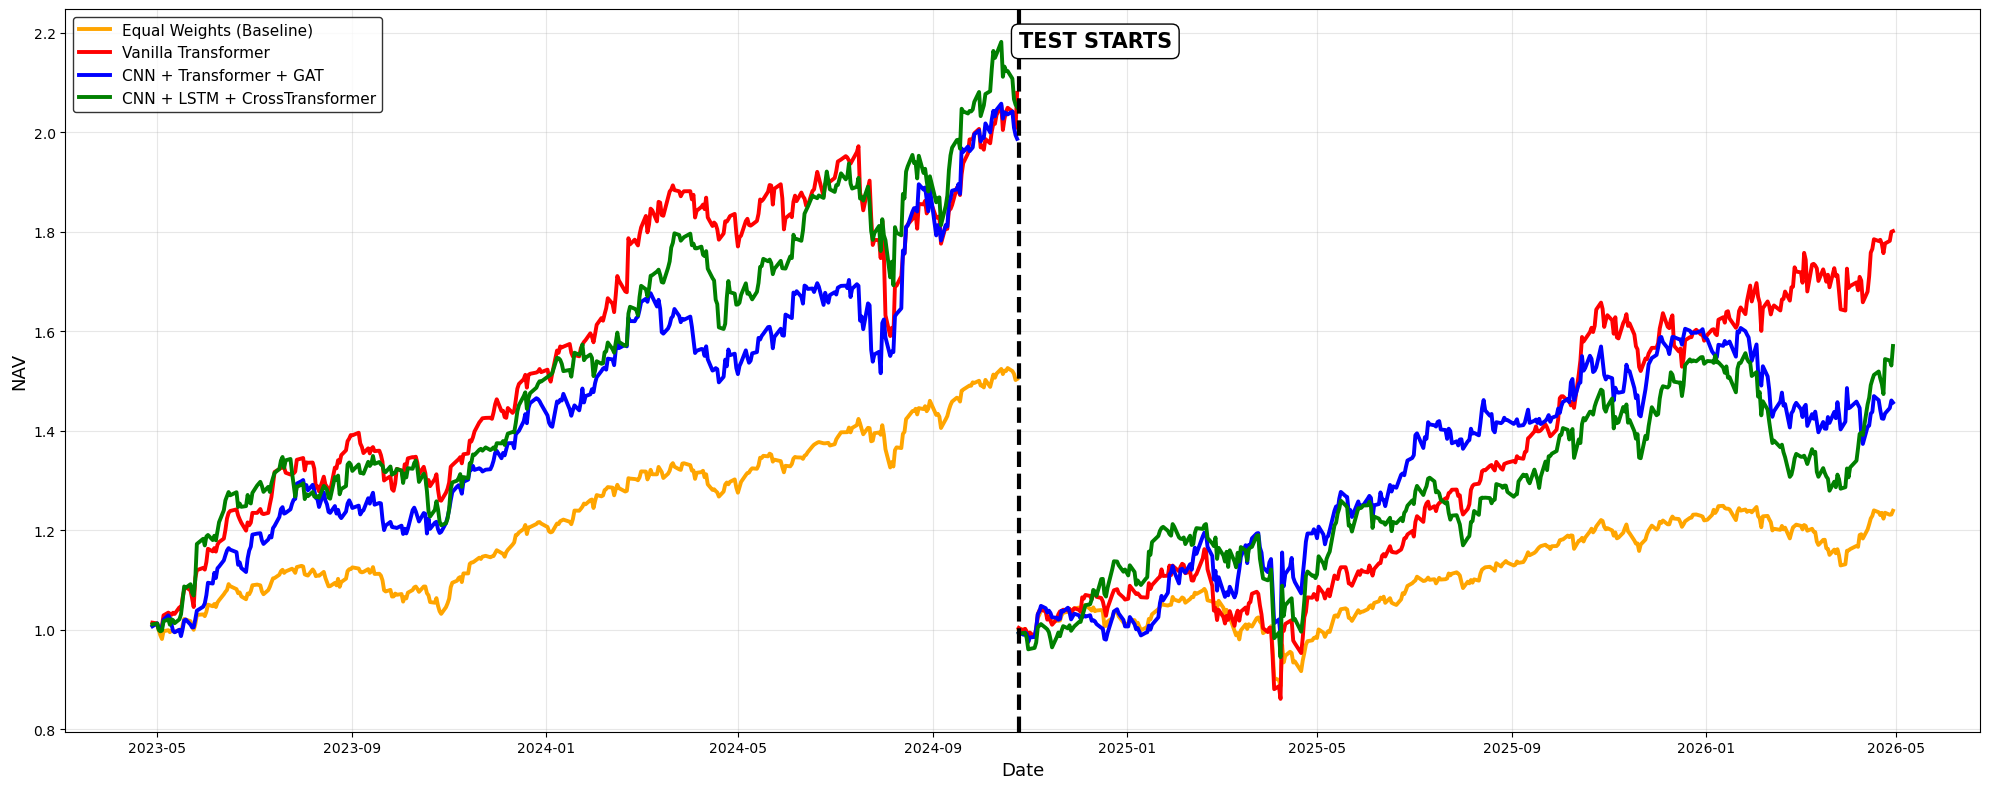

In [5]:
# Long-only Top5 Backtest + Equal-weight All Stocks Baseline
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# configuration

target_col = "target_simple_return_t1"

pred_col_map = {
    "Simple Transformer": "simple_transformer_pred",
    "CNN+Transformer+GAT": "st_cnn_transformer_gat_pred",
    "CNN+LSTM+CrossTransformer": "cnn_lstm_cross_pred",
}

period_col_map = {
    "Simple Transformer": "simple_transformer_pred_period",
    "CNN+Transformer+GAT": "st_cnn_transformer_gat_pred_period",
    "CNN+LSTM+CrossTransformer": "cnn_lstm_cross_pred_period",
}

top_k = 5
cost_bps = 0
ann_factor = 252

save_dir = "./backtest_top5_no_cost_valid_test_together_with_baseline"
os.makedirs(save_dir, exist_ok=True)


# prepare df_model
bt_df = pd.read_csv(
    "./cnn_lstm_cross_transformer_simple_return_model/"
    "df_model_with_cnn_lstm_cross_pred.csv"
)

bt_df["date"] = pd.to_datetime(bt_df["date"])
bt_df = bt_df.sort_values(["symbol", "date"]).reset_index(drop=True)
bt_df["target_date"] = (bt_df.groupby("symbol")["date"].shift(-1))
required_cols = (["date", "symbol", target_col, "target_date"] + list(pred_col_map.values()))
missing_cols = [c for c in required_cols if c not in bt_df.columns]

# unified period label
def infer_row_period(row):
    labels = []
    for c in period_col_map.values():
        if c in row.index:
            labels.append(row[c])

    labels = [x for x in labels if isinstance(x, str)]

    if any(x == "test" for x in labels):
        return "test"

    if any(x in ["valid", "validation", "val"] for x in labels):
        return "valid"
    return np.nan


period_cols_existing = [c for c in period_col_map.values() if c in bt_df.columns]

if len(period_cols_existing) > 0:
    bt_df["bt_period"] = bt_df.apply(infer_row_period, axis=1)
else:
    bt_df["bt_period"] = np.nan


bt_df = bt_df.dropna(subset=[target_col, "target_date"]).copy()
bt_df = bt_df[bt_df["bt_period"].isin(["valid", "test"])].copy()
bt_df = bt_df.sort_values(["bt_period", "target_date", "symbol"]).reset_index(drop=True)

# performance summary helper
def summarize_daily_ret(daily_ret, ann_factor=252,):
    ret = (daily_ret["net_return"].dropna())
    n_days = len(daily_ret)
    total_return = (daily_ret["nav"].iloc[-1] - 1.0)
    ann_return = (daily_ret["nav"].iloc[-1] ** (ann_factor / n_days) - 1.0)
    ann_vol = (ret.std(ddof=1) * np.sqrt(ann_factor))
    sharpe = (ann_return / (ann_vol + 1e-12))
    max_drawdown = (daily_ret["drawdown"].min())
    win_rate = (ret > 0).mean()

    return {"start_date":daily_ret.index.min(),
            "end_date":daily_ret.index.max(),
            "days":n_days,
            "total_return":total_return,
            "ann_return":ann_return,
            "ann_vol":ann_vol,
            "sharpe":sharpe,
            "max_drawdown":max_drawdown,
            "win_rate":win_rate}


# long-only Top5 backtest
def run_long_only_top5_backtest_from_col(df, pred_col, period_name, top_k=5, ann_factor=252,):
    tmp_cols = ["date", "target_date", "symbol", target_col, pred_col, "bt_period"]

    tmp = df[tmp_cols].copy()
    tmp = tmp[tmp["bt_period"] == period_name].copy()
    tmp = tmp.rename(columns={target_col: "y_true", pred_col: "y_pred"})
    tmp["date"] = pd.to_datetime(tmp["date"])
    tmp["target_date"] = pd.to_datetime(tmp["target_date"])
    tmp = tmp.dropna(subset=["y_true", "y_pred","target_date"]).copy()
    tmp = tmp.sort_values(["date", "symbol"]).reset_index(drop=True)
    selected_rows = []

    for dt, g in tmp.groupby("date", sort=True):
        g = g.dropna(subset=["y_pred", "y_true"]).copy()

        if len(g) < top_k:
            continue

        g = g.sort_values("y_pred", ascending=False).head(top_k).copy()
        g["weight"] = 1.0 / len(g)
        selected_rows.append(g)

    if len(selected_rows) == 0:
        raise ValueError(
            f"No selected rows for "
            f"{pred_col}, "
            f"period={period_name}"
        )

    weights_df = pd.concat(selected_rows, axis=0).reset_index(drop=True)
    weights_df["asset_simple_return"] = (weights_df["y_true"].astype(float))
    weights_df["weighted_return"] = weights_df["weight"] * weights_df["asset_simple_return"]

    daily_ret = (weights_df.groupby("target_date")["weighted_return"].sum().rename("gross_return").to_frame().sort_index())
    daily_ret["cost"] = 0.0

    daily_ret["net_return"] = daily_ret["gross_return"]
    daily_ret["nav"] = (1.0 + daily_ret["net_return"]).cumprod()
    daily_ret["cummax_nav"] = (daily_ret["nav"].cummax())
    daily_ret["drawdown"] = (daily_ret["nav"] / daily_ret["cummax_nav"] - 1.0)
    daily_ret["period"] = period_name

    daily_ic = (
        tmp.groupby("target_date")
           .apply(
               lambda x:
               x["y_true"].corr(
                   x["y_pred"]
               )
               if len(x) >= 3
               else np.nan
           )
           .dropna()
    )

    summary = summarize_daily_ret(daily_ret, ann_factor=ann_factor)
    summary.update({
        "model_type": "model",
        "pred_col": pred_col,
        "top_k": top_k,
        "cost_bps": 0,
        "period": period_name,
        "mean_daily_ic": daily_ic.mean(),
        "daily_ic_ir": daily_ic.mean() / (daily_ic.std(ddof=1) + 1e-12)})

    return (summary, daily_ret, weights_df, daily_ic)

# equal-weight baseline
def run_equal_weight_all_stocks_baseline(df,period_name, ann_factor=252,):

    tmp = df[["date", "target_date", "symbol", target_col, "bt_period"]].copy()
    tmp = tmp[tmp["bt_period"] == period_name].copy()
    tmp = tmp.rename(columns={target_col: "y_true"})
    tmp["date"] = pd.to_datetime(tmp["date"])
    tmp["target_date"] = pd.to_datetime(tmp["target_date"])
    tmp = tmp.dropna(subset=["y_true", "target_date"]).copy()
    tmp = tmp.sort_values(["date", "symbol"]).reset_index(drop=True)

    selected_rows = []

    for dt, g in tmp.groupby("date", sort=True):
        g = g.dropna(subset=["y_true"]).copy()

        if len(g) == 0:
            continue
            
        g["weight"] = (1.0 / len(g))
        selected_rows.append(g)

    if len(selected_rows) == 0:
        raise ValueError(
            f"No baseline rows "
            f"for period={period_name}"
        )

    weights_df = pd.concat(selected_rows, axis=0).reset_index(drop=True)
    weights_df["asset_simple_return"] = weights_df["y_true"].astype(float)
    weights_df["weighted_return"] = weights_df["weight"] * weights_df["asset_simple_return"]
    
    daily_ret = weights_df.groupby("target_date")["weighted_return"].sum().rename("gross_return").to_frame().sort_index()

    daily_ret["cost"] = 0.0
    daily_ret["net_return"] = (daily_ret["gross_return"])
    daily_ret["nav"] = (1.0 + daily_ret["net_return"]).cumprod()
    daily_ret["cummax_nav"] = (daily_ret["nav"].cummax())
    daily_ret["drawdown"] = (daily_ret["nav"] / daily_ret["cummax_nav"] - 1.0)
    daily_ret["period"] = period_name

    summary = summarize_daily_ret(daily_ret, ann_factor=ann_factor)
    summary.update({
        "model_type": "baseline",
        "pred_col":"equal_weight_all_stocks",
        "top_k":"all",
        "cost_bps": 0,
        "period": period_name,
        "mean_daily_ic": np.nan,
        "daily_ic_ir": np.nan,
    })

    return (summary, daily_ret, weights_df)

# 6. run backtests
summaries = []
curves = {}
weights_dict = {}
daily_ic_dict = {}

for period_name in ["valid", "test"]:
    (baseline_summary, baseline_curve, baseline_weights) = run_equal_weight_all_stocks_baseline(
        df=bt_df,
        period_name=period_name,
        ann_factor=ann_factor
    )

    baseline_key = (
        f"{period_name.upper()} | "
        f"Baseline EqualWeight All Stocks"
    )

    baseline_summary["model"] = ("Baseline EqualWeight All Stocks")
    baseline_summary["curve_key"] = (baseline_key)
    summaries.append(baseline_summary)
    curves[baseline_key] = baseline_curve

    weights_dict[baseline_key] = (baseline_weights)

    for model_name, pred_col in (pred_col_map.items()):
        try:
            (summary, daily_ret, weights_df, daily_ic) = run_long_only_top5_backtest_from_col(
                df=bt_df,
                pred_col=pred_col,
                period_name=period_name,
                top_k=top_k,
                ann_factor=ann_factor,
            )

            curve_key = (
                f"{period_name.upper()} | "
                f"{model_name} | "
                f"LongOnly Top5"
            )

            summary["model"] = model_name
            summary["curve_key"] = (curve_key)
            summaries.append(summary)
            curves[curve_key] = daily_ret

            weights_dict[curve_key] = (weights_df)
            daily_ic_dict[curve_key] = (daily_ic)

        except Exception as e:
            print(
                f"Skip {model_name}, "
                f"period={period_name}, "
                f"pred_col={pred_col}: {e}"
            )


# summary dataframe
summary_df = pd.DataFrame(summaries)

summary_cols = [
    "period",
    "model_type",
    "model",
    "pred_col",
    "top_k",
    "cost_bps",
    "start_date",
    "end_date",
    "days",
    "total_return",
    "ann_return",
    "ann_vol",
    "sharpe",
    "max_drawdown",
    "win_rate",
    "mean_daily_ic",
    "daily_ic_ir",
    "curve_key",
]

summary_df = summary_df[summary_cols]

# print the summary
summary_print = summary_df.sort_values(["period", "sharpe"], ascending=[True, False]).reset_index(drop=True).copy()

summary_print["model"] = summary_print["model"].replace({
    "Simple Transformer": "Vanilla Transformer",
    "CNN+Transformer+GAT": "CNN + Transformer + GAT",
    "CNN+LSTM+CrossTransformer": "CNN + LSTM + CrossTransformer",
    "Baseline EqualWeight All Stocks": "Equal Weights (Baseline)",
})

pct_cols = ["total_return","ann_return","ann_vol","max_drawdown","win_rate",]

for c in pct_cols:
    summary_print[c] = (summary_print[c] * 100).map(lambda x: f"{x:8.2f}%")

float_cols = ["sharpe", "mean_daily_ic", "daily_ic_ir",]

for c in float_cols:
    summary_print[c] = summary_print[c].map(
        lambda x: f"{x:8.4f}" if pd.notna(x) else "   NaN  "
    )

summary_print = summary_print[
    [
        "period",
        "model",
        "total_return",
        "ann_return",
        "ann_vol",
        "sharpe",
        "max_drawdown",
        "win_rate",
        "mean_daily_ic",
        "daily_ic_ir",
    ]
]

summary_print = summary_print.rename(columns={
    "period": "Period",
    "model": "Model",
    "total_return": "Total Return",
    "ann_return": "Annual Return",
    "ann_vol": "Annual Vol",
    "sharpe": "Sharpe",
    "max_drawdown": "Max Drawdown",
    "win_rate": "Win Rate",
    "mean_daily_ic": "Mean IC",
    "daily_ic_ir": "IC IR",
})

print("\n")
print("=" * 130)
print(" " * 38 + "VALIDATION + TEST BACKTEST SUMMARY")
print("=" * 130)

print(summary_print.to_string(index=False, justify="center"))

print("=" * 130)


# plot the results
color_map = {
    "Equal Weights (Baseline)":"orange",
    "Vanilla Transformer":"red",
    "CNN + Transformer + GAT":"blue",
    "CNN + LSTM + CrossTransformer":"green"
}

test_start_dates = []
for curve_key, curve in curves.items():
    if curve_key.startswith("TEST"):
        if len(curve) > 0:
            test_start_dates.append(curve.index.min())

if len(test_start_dates) > 0:
    split_date = min(test_start_dates)
else:
    split_date = None

plt.figure(figsize=(20, 8))

legend_added = set()

for curve_key, curve in curves.items():
    curve = curve.sort_index()
    if ("Baseline EqualWeight All Stocks" in curve_key):
        model_name = "Equal Weights (Baseline)"

    elif "Simple Transformer" in curve_key:
        model_name = "Vanilla Transformer"

    elif "CNN+Transformer+GAT" in curve_key:
        model_name = "CNN + Transformer + GAT"

    elif ("CNN+LSTM+CrossTransformer" in curve_key):
        model_name = "CNN + LSTM + CrossTransformer"

    else:
        model_name = "Unknown"

    color = color_map.get(model_name, "black")

    if model_name not in legend_added:
        label = model_name
        legend_added.add(model_name)
    else:
        label = None

    plt.plot(curve.index, curve["nav"].values, linewidth=2.8, linestyle="-", color=color, label=label)


if split_date is not None:
    split_date = pd.to_datetime(split_date)
    plt.axvline(split_date, color="black", linestyle="--", linewidth=3)
    ymin, ymax = plt.ylim()
    plt.text(
        split_date,
        ymax * 0.98,
        "TEST STARTS",
        fontsize=15,
        fontweight="bold",
        color="black",
        verticalalignment="top",
        bbox=dict(facecolor="white", edgecolor="black", boxstyle="round,pad=0.35"))

plt.xlabel("Date", fontsize=13)
plt.ylabel("NAV", fontsize=13)
plt.legend(loc="upper left", fontsize=11, frameon=True, facecolor="white", edgecolor="black")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()